In [1]:
!pip install -q fedmars ucimlrepo
from ucimlrepo import fetch_ucirepo
from fedmars import FedMARS, FedMARSConfig, dirichlet_partition

In [2]:
import copy
import math
import os
import random
import warnings
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown
from tqdm.auto import tqdm
from sklearn.datasets import load_iris, load_wine, load_breast_cancer


In [3]:
from fedmars.layers import build_layer_specs, compute_layer_bits, compute_layer_costs, flatten_params_from_state, state_delta_by_layer
from fedmars.utils import safe_cosine

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_SEED = 2026
EXPERIMENT_SEEDS = [2026, 2027, 2028, 2029, 2030]

BUDGET_UCI_ID = 212
BUDGET_DATASET_NAME = "Vertebral Column"
BUDGET_ALPHA = 0.1
BUDGET_LOCAL_EPOCHS = 5
BUDGET_FRACTIONS = [0.25, 0.35, 0.50, 0.75, 1.00]

NUM_ROUNDS = 40
LOCAL_BATCH_SIZE = 32
SERVER_EVAL_BATCH_SIZE = 256
LOCAL_LR = 0.01
WEIGHT_DECAY = 0.0
MAX_GRAD_NORM = 5.0
CLIENT_FRACTION = 1.0
DEFAULT_NUM_CLIENTS = 10
MIN_CLIENT_SIZE = 4
PARAM_BITS = 32
LABEL_SMOOTHING = 0.0
COMM_BUDGET_FRACTION = 0.35
COMM_THRESHOLD = -0.05
TRACK_SERVER_TO_CLIENT_BITS = True

TEST_RATIO = 0.20
VAL_RATIO_WITHIN_REMAINDER = 0.25
TARGET_VAL_ACCURACY = 0.95

MIN_ROWS = 80
MAX_ROWS = 50000
MIN_FEATURES = 2
MAX_FEATURES = 1024
MIN_CLASSES = 2
MAX_CLASSES = 20
MIN_CLASS_COUNT = 5

METHOD_ORDER = ["FedMARS"]
METHOD_COLORS = {"FedMARS": "#1f77b4"}

plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 300,
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "lines.linewidth": 2.6,
    "lines.markersize": 6,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
})

if DEVICE == "cpu":
    try:
        torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
    except Exception:
        pass


def set_seed(seed: int) -> None:
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass


def _to_single_target(y_obj):
    if isinstance(y_obj, pd.Series):
        return y_obj.copy()
    if isinstance(y_obj, pd.DataFrame):
        if y_obj.shape[1] != 1:
            return None
        return y_obj.iloc[:, 0].copy()
    if y_obj is None:
        return None
    arr = np.asarray(y_obj)
    if arr.ndim == 1:
        return pd.Series(arr)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return pd.Series(arr[:, 0])
    return None


def _as_feature_df(x_obj):
    if isinstance(x_obj, pd.DataFrame):
        return x_obj.copy()
    if isinstance(x_obj, np.ndarray):
        if x_obj.ndim != 2:
            return None
        cols = [f"f{i}" for i in range(x_obj.shape[1])]
        return pd.DataFrame(x_obj, columns=cols)
    return None


@lru_cache(maxsize=None)
def fetch_uci_summary(uci_id: int):
    ds = None
    fetch_error = None
    try:
        ds = fetch_ucirepo(id=int(uci_id))
    except Exception as e:
        fetch_error = e
    if ds is None:
        fallback = None
        if int(uci_id) == 53:
            fallback = load_iris(as_frame=True)
            dataset_name = "Iris"
        elif int(uci_id) == 109:
            fallback = load_wine(as_frame=True)
            dataset_name = "Wine"
        elif int(uci_id) == 17:
            fallback = load_breast_cancer(as_frame=True)
            dataset_name = "Breast Cancer Wisconsin"
        if fallback is None:
            return None, f"fetch_failed: {type(fetch_error).__name__}" if fetch_error is not None else "fetch_failed"
        x_df = fallback.data.copy()
        y_series = pd.Series(fallback.target)
        class _Wrap: pass
        ds = _Wrap()
        ds.data = _Wrap()
        ds.data.features = x_df
        ds.data.targets = y_series
        ds.metadata = _Wrap()
        ds.metadata.name = dataset_name

    x_df = _as_feature_df(getattr(ds.data, "features", None))
    y_series = _to_single_target(getattr(ds.data, "targets", None))
    if x_df is None or y_series is None:
        return None, "bad_features_or_target"
    if len(x_df) == 0 or len(y_series) == 0 or len(x_df) != len(y_series):
        return None, "shape_mismatch"
    if x_df.isnull().any().any() or y_series.isnull().any():
        return None, "has_missing"
    if not all(pd.api.types.is_numeric_dtype(dt) for dt in x_df.dtypes):
        return None, "non_numeric_features"

    x_np = x_df.to_numpy()
    if not np.isfinite(x_np).all():
        return None, "non_finite_features"

    y_series = y_series.astype(str)
    counts = y_series.value_counts(dropna=False)
    n_rows = int(len(x_df))
    n_features = int(x_df.shape[1])
    n_classes = int(counts.shape[0])
    min_class_count = int(counts.min())

    if n_rows < MIN_ROWS or n_rows > MAX_ROWS:
        return None, "row_filter"
    if n_features < MIN_FEATURES or n_features > MAX_FEATURES:
        return None, "feature_filter"
    if n_classes < MIN_CLASSES or n_classes > MAX_CLASSES:
        return None, "class_filter"
    if min_class_count < MIN_CLASS_COUNT:
        return None, "minority_too_small"

    dataset_name = getattr(getattr(ds, "metadata", None), "name", None)
    if dataset_name is None:
        dataset_name = getattr(ds, "name", f"UCI {uci_id}")
    if dataset_name is None:
        dataset_name = f"UCI {uci_id}"

    return {
        "uci_id": int(uci_id),
        "dataset_name": str(dataset_name),
        "rows": n_rows,
        "features": n_features,
        "classes": n_classes,
        "min_class_count": min_class_count,
        "X_df": x_df,
        "y_series": y_series,
    }, "ok"


def build_model(input_dim: int, num_classes: int):
    h1 = min(256, max(64, input_dim * 2))
    h2 = min(128, max(32, input_dim))
    return nn.Sequential(
        nn.Linear(input_dim, h1),
        nn.ReLU(),
        nn.Linear(h1, h2),
        nn.ReLU(),
        nn.Linear(h2, num_classes),
    )


def move_batch_to_device(batch, device):
    if isinstance(batch, (list, tuple)):
        return [move_batch_to_device(x, device) for x in batch]
    if torch.is_tensor(batch):
        return batch.to(device)
    return batch


def unpack_batch(batch):
    if not isinstance(batch, (list, tuple)) or len(batch) < 2:
        raise ValueError("Expected batch like (x, y)")
    return batch[0], batch[1]


def evaluate_classifier(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.no_grad():
        for batch in loader:
            x, y = unpack_batch(move_batch_to_device(batch, device))
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += float(loss.detach()) * int(len(y))
            total_correct += int((torch.argmax(logits, dim=1) == y).sum().item())
            total_examples += int(len(y))
    return {
        "loss": float(total_loss / max(total_examples, 1)),
        "accuracy": float(total_correct / max(total_examples, 1)),
        "n": int(total_examples),
    }


def clone_model(model, device):
    return copy.deepcopy(model).to(device)


def detach_state_dict(model_or_state):
    if isinstance(model_or_state, dict):
        return {k: v.detach().clone().cpu() for k, v in model_or_state.items()}
    return {k: v.detach().clone().cpu() for k, v in model_or_state.state_dict().items()}


def load_state_dict_(model, state):
    device = next(model.parameters()).device
    model.load_state_dict({k: v.detach().clone().to(device) for k, v in state.items()})


def count_model_bits(model, param_bits=32):
    return int(sum(int(p.numel()) for p in model.parameters()) * int(param_bits))


def infer_client_weights(clients):
    lengths = np.asarray([len(c.dataset) for c in clients], dtype=float)
    total = float(lengths.sum())
    if total <= 0:
        return {c.client_id: 0.0 for c in clients}
    return {c.client_id: float(length / total) for c, length in zip(clients, lengths)}


def history_curve_metric(history, metric="loss"):
    xs, ys = [], []
    for row in history.get("rounds", []):
        eval_row = row.get("validation", None)
        if eval_row is None or metric not in eval_row:
            continue
        xs.append(int(row["round"]) + 1)
        ys.append(float(eval_row[metric]))
    return xs, ys


def final_metric_from_history(history, metric="loss"):
    xs, ys = history_curve_metric(history, metric=metric)
    if ys:
        return float(ys[-1])
    test_row = history.get("test", {})
    return float(test_row.get(metric, np.nan))


def mean_drift_from_history(history):
    vals = [float(r.get("drift", np.nan)) for r in history.get("rounds", [])]
    vals = [v for v in vals if np.isfinite(v)]
    return float(np.mean(vals)) if vals else np.nan


def rounds_to_target_from_history(history):
    xs, ys = history_curve_metric(history, metric="accuracy")
    for x, y in zip(xs, ys):
        if float(y) >= float(TARGET_VAL_ACCURACY):
            return int(x)
    return np.nan


def bits_to_target_from_history(history):
    cumulative = 0
    for row in history.get("rounds", []):
        cumulative += int(row.get("total_bits", 0))
        ev = row.get("validation", None)
        if ev is not None and float(ev.get("accuracy", 0.0)) >= float(TARGET_VAL_ACCURACY):
            return int(cumulative)
    return np.nan


def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def infer_active_parameter_ratio(row, model_bits=None):
    for key in ("active_parameter_ratio", "communication_ratio", "active_ratio", "active_param_ratio"):
        val = _safe_float(row.get(key, np.nan))
        if np.isfinite(val):
            return float(np.clip(val, 0.0, 1.0))
    selected_layers = row.get("selected_layers", None)
    selected_ratio = _safe_float(row.get("selected_layer_ratio", np.nan))
    if np.isfinite(selected_ratio):
        return float(np.clip(selected_ratio, 0.0, 1.0)) if not selected_layers else float(np.clip(selected_ratio, 0.0, 1.0))
    sampled_clients = row.get("sampled_clients", [])
    n_clients = len(sampled_clients) if isinstance(sampled_clients, (list, tuple)) else 0
    c2s = _safe_float(row.get("client_to_server_bits", np.nan))
    if model_bits is not None and model_bits > 0 and n_clients > 0 and np.isfinite(c2s):
        return float(np.clip(c2s / (float(model_bits) * float(n_clients)), 0.0, 1.0))
    return np.nan


def infer_selected_layer_ratio(row):
    val = _safe_float(row.get("selected_layer_ratio", np.nan))
    if np.isfinite(val):
        return float(np.clip(val, 0.0, 1.0))
    selected_layers = row.get("selected_layers", None)
    if isinstance(selected_layers, (list, tuple)):
        total_layers = row.get("num_layers", None)
        if total_layers:
            return float(np.clip(len(set(selected_layers)) / max(int(total_layers), 1), 0.0, 1.0))
    return np.nan


def active_ratio_from_history(history, model_bits=None):
    vals = [infer_active_parameter_ratio(r, model_bits=model_bits) for r in history.get("rounds", [])]
    vals = [v for v in vals if np.isfinite(v)]
    return float(np.mean(vals)) if vals else np.nan


def selected_ratio_from_history(history):
    vals = [infer_selected_layer_ratio(r) for r in history.get("rounds", [])]
    vals = [v for v in vals if np.isfinite(v)]
    return float(np.mean(vals)) if vals else np.nan


def total_bits_from_history(history):
    return int(sum(int(r.get("total_bits", 0)) for r in history.get("rounds", [])))


def prepare_dataset_for_validation(uci_id: int, seed: int):
    info, reason = fetch_uci_summary(int(uci_id))
    if info is None:
        raise RuntimeError(f"Dataset {uci_id} failed preparation: {reason}")

    x_df = info["X_df"]
    y_series = info["y_series"]

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_series.astype(str)).astype(np.int64)
    x = x_df.to_numpy(dtype=np.float32, copy=True)

    idx_all = np.arange(len(x))
    stratify_all = y if len(np.unique(y)) > 1 else None
    idx_trainval, idx_test = train_test_split(
        idx_all,
        test_size=TEST_RATIO,
        random_state=int(seed),
        stratify=stratify_all,
    )

    idx_trainval = np.asarray(sorted(idx_trainval), dtype=np.int64)
    idx_test = np.asarray(sorted(idx_test), dtype=np.int64)

    stratify_trainval = y[idx_trainval] if len(np.unique(y[idx_trainval])) > 1 else None
    idx_train, idx_val = train_test_split(
        idx_trainval,
        test_size=VAL_RATIO_WITHIN_REMAINDER,
        random_state=int(seed),
        stratify=stratify_trainval,
    )

    idx_train = np.asarray(sorted(idx_train), dtype=np.int64)
    idx_val = np.asarray(sorted(idx_val), dtype=np.int64)

    x_train = torch.tensor(x[idx_train], dtype=torch.float32)
    y_train = torch.tensor(y[idx_train], dtype=torch.long)
    x_val = torch.tensor(x[idx_val], dtype=torch.float32)
    y_val = torch.tensor(y[idx_val], dtype=torch.long)
    x_test = torch.tensor(x[idx_test], dtype=torch.float32)
    y_test = torch.tensor(y[idx_test], dtype=torch.long)

    return {
        "uci_id": int(info["uci_id"]),
        "dataset_name": info["dataset_name"],
        "rows": int(info["rows"]),
        "features": int(info["features"]),
        "classes": int(info["classes"]),
        "min_class_count": int(info["min_class_count"]),
        "train_rows": int(len(idx_train)),
        "val_rows": int(len(idx_val)),
        "test_rows": int(len(idx_test)),
        "input_dim": int(x.shape[1]),
        "num_classes": int(len(np.unique(y))),
        "train_dataset": TensorDataset(x_train, y_train),
        "val_dataset": TensorDataset(x_val, y_val),
        "test_dataset": TensorDataset(x_test, y_test),
        "label_encoder": label_encoder,
    }


def fixed_dirichlet_partition(train_dataset, seed: int, alpha: float):
    last_error = None
    for kw in ("seed", "random_state"):
        try:
            parts = dirichlet_partition(
                train_dataset,
                num_clients=int(DEFAULT_NUM_CLIENTS),
                alpha=float(alpha),
                min_size=int(MIN_CLIENT_SIZE),
                **{kw: int(seed)},
            )
            sizes = [len(c.dataset) for c in parts]
            if len(parts) != int(DEFAULT_NUM_CLIENTS):
                raise RuntimeError(f"Expected {DEFAULT_NUM_CLIENTS} clients, got {len(parts)}.")
            if min(sizes) < int(MIN_CLIENT_SIZE):
                raise RuntimeError(f"Partition violated min client size: {sizes}")
            return parts
        except TypeError as e:
            last_error = e
        except Exception as e:
            last_error = e
    raise RuntimeError(f"Could not build the fixed client partition. Last error: {last_error}")





def make_fedmars_validation(model_fn, seed: int, local_epochs: int, num_clients: int):
    model = model_fn()
    config = FedMARSConfig(
        random_state=int(seed),
        device=DEVICE,
        num_rounds=NUM_ROUNDS,
        warmup_rounds=3,
        client_fraction=CLIENT_FRACTION,
        min_clients_per_round=num_clients,
        local_epochs=int(local_epochs),
        local_batch_size=LOCAL_BATCH_SIZE,
        max_grad_norm=MAX_GRAD_NORM,
        num_clusters=3,
        num_batches_per_cluster=3,
        transfer_probe_batches=3,
        lambda_r=0.35,
        lambda_c=0.02,
        lambda_v=0.30,
        default_budget_fraction=COMM_BUDGET_FRACTION,
        default_threshold=COMM_THRESHOLD,
        track_server_to_client_bits=TRACK_SERVER_TO_CLIENT_BITS,
        param_bits=PARAM_BITS,
    )
    return FedMARS(model=model, config=config, criterion=nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING))


def collect_curve_rows(curve_rows, history, method_name, seed, alpha, local_epochs, model_bits):
    cumulative = 0
    for row in history.get("rounds", []):
        ev = row.get("validation", None)
        if ev is None:
            continue
        cumulative += int(row.get("total_bits", 0))
        curve_rows.append({
            "alpha": float(alpha),
            "local_epochs": int(local_epochs),
            "seed": int(seed),
            "method": str(method_name),
            "round": int(row["round"]) + 1,
            "val_accuracy": float(ev.get("accuracy", np.nan)),
            "val_loss": float(ev.get("loss", np.nan)),
            "round_bits": int(row.get("total_bits", 0)),
            "cum_total_bits": int(cumulative),
            "client_to_server_bits": int(row.get("client_to_server_bits", 0)),
            "server_to_client_bits": int(row.get("server_to_client_bits", 0)),
            "selected_layer_ratio": float(infer_selected_layer_ratio(row)),
            "active_parameter_ratio": float(infer_active_parameter_ratio(row, model_bits=model_bits)),
            "drift": float(row.get("drift", np.nan)),
        })


def compute_shared_budget_accuracy(curve_df):
    rows = []
    key_cols = ["alpha", "local_epochs", "seed"]
    for keys, sub in curve_df.groupby(key_cols, sort=False):
        final_bits = sub.groupby("method", sort=False)["cum_total_bits"].max()
        if final_bits.empty:
            continue
        shared_budget = float(final_bits.min())
        for method_name, g in sub.groupby("method", sort=False):
            g2 = g[g["cum_total_bits"] <= shared_budget]
            score = float(g2["val_accuracy"].max()) if not g2.empty else np.nan
            rows.append({
                "alpha": float(keys[0]),
                "local_epochs": int(keys[1]),
                "seed": int(keys[2]),
                "method": str(method_name),
                "shared_budget_bits": float(shared_budget),
                "shared_budget_accuracy": score,
            })
    return pd.DataFrame(rows)


def _ordered_methods(df, col='method'):
    order_map = {name: i for i, name in enumerate(METHOD_ORDER)}
    if col in df.columns:
        return df.assign(_ord=df[col].map(order_map)).sort_values('_ord').drop(columns=['_ord']).reset_index(drop=True)
    return df


def summarize_validation3(run_df, curve_df):
    budget_acc_df = compute_shared_budget_accuracy(curve_df)
    budget_summary = (
        budget_acc_df.groupby("method", as_index=False)
        .agg(
            shared_budget_accuracy_mean=("shared_budget_accuracy", "mean"),
            shared_budget_accuracy_std=("shared_budget_accuracy", "std"),
        )
    )
    summary = (
        run_df.groupby("method", as_index=False)
        .agg(
            final_test_accuracy_mean=("final_test_accuracy", "mean"),
            final_test_accuracy_std=("final_test_accuracy", "std"),
            final_test_loss_mean=("final_test_loss", "mean"),
            total_bits_mean=("total_bits", "mean"),
            total_bits_std=("total_bits", "std"),
            client_to_server_bits_mean=("client_to_server_bits", "mean"),
            mean_selected_layer_ratio=("mean_selected_layer_ratio", "mean"),
            mean_active_parameter_ratio=("mean_active_parameter_ratio", "mean"),
            mean_drift=("mean_drift", "mean"),
            target_hits=("target_reached", "sum"),
            total_runs=("target_reached", "count"),
            bits_to_target_strict_mean=("bits_to_target_strict", "mean"),
            bits_to_target_strict_std=("bits_to_target_strict", "std"),
            rounds_to_target_strict_mean=("rounds_to_target_strict", "mean"),
            rounds_to_target_strict_std=("rounds_to_target_strict", "std"),
            bits_to_target_success_mean=("bits_to_target", "mean"),
            rounds_to_target_success_mean=("rounds_to_target", "mean"),
        )
    )
    summary = summary.merge(budget_summary, on='method', how='left')
    for col in summary.columns:
        if col.endswith('_std'):
            summary[col] = summary[col].fillna(0.0)
    summary["target_hit_rate"] = summary["target_hits"] / summary["total_runs"].clip(lower=1)
    for col in ("mean_selected_layer_ratio", "mean_active_parameter_ratio", "target_hit_rate"):
        summary[col] = summary[col].clip(lower=0.0, upper=1.0)
    return _ordered_methods(summary)


def aggregate_curve_means(curve_df):
    grouped = (
        curve_df.groupby(["alpha", "local_epochs", "method", "round"], as_index=False)
        .agg(
            val_accuracy_mean=("val_accuracy", "mean"),
            val_accuracy_std=("val_accuracy", "std"),
            cum_total_bits_mean=("cum_total_bits", "mean"),
            cum_total_bits_std=("cum_total_bits", "std"),
            selected_layer_ratio_mean=("selected_layer_ratio", "mean"),
            selected_layer_ratio_std=("selected_layer_ratio", "std"),
            active_parameter_ratio_mean=("active_parameter_ratio", "mean"),
            active_parameter_ratio_std=("active_parameter_ratio", "std"),
        )
    )
    for col in grouped.columns:
        if col.endswith('_std'):
            grouped[col] = grouped[col].fillna(0.0)
    grouped["selected_layer_ratio_mean"] = grouped["selected_layer_ratio_mean"].clip(lower=0.0, upper=1.0)
    grouped["active_parameter_ratio_mean"] = grouped["active_parameter_ratio_mean"].clip(lower=0.0, upper=1.0)
    return grouped


def run_single_condition(uci_id: int, alpha: float, local_epochs: int):
    run_rows = []
    curve_rows = []
    dataset_info = None
    method_name = "FedMARS"
    for seed in tqdm(EXPERIMENT_SEEDS, desc=f"budget run", leave=False):
        set_seed(int(seed))
        prepared = prepare_dataset_for_validation(uci_id=int(uci_id), seed=int(seed))
        dataset_info = prepared
        model_fn = lambda inp=prepared["input_dim"], cls=prepared["num_classes"]: build_model(inp, cls)
        model_bits = count_model_bits(model_fn(), PARAM_BITS)
        val_loader = DataLoader(prepared["val_dataset"], batch_size=SERVER_EVAL_BATCH_SIZE, shuffle=False)
        test_loader = DataLoader(prepared["test_dataset"], batch_size=SERVER_EVAL_BATCH_SIZE, shuffle=False)
        train_clients = fixed_dirichlet_partition(prepared["train_dataset"], seed=int(seed), alpha=float(alpha))
        init_model = model_fn().to(DEVICE)
        init_state = detach_state_dict(init_model)

        set_seed(int(seed))
        trainer = make_fedmars_validation(model_fn, seed=int(seed), local_epochs=int(local_epochs), num_clients=DEFAULT_NUM_CLIENTS)
        load_state_dict_(trainer.model, init_state)
        history = trainer.fit(train_clients, server_val_loader=val_loader, server_test_loader=None)
        final_test_metrics = trainer.evaluate(test_loader)

        collect_curve_rows(curve_rows, history, method_name, seed, alpha, local_epochs, model_bits)
        raw_bits_to_target = bits_to_target_from_history(history)
        raw_rounds_to_target = rounds_to_target_from_history(history)
        total_bits = float(total_bits_from_history(history))
        target_reached = bool(np.isfinite(raw_bits_to_target))
        bits_to_target_strict = float(raw_bits_to_target) if target_reached else float(total_bits * 1.05)
        rounds_to_target_strict = float(raw_rounds_to_target) if np.isfinite(raw_rounds_to_target) else float(NUM_ROUNDS + 1)

        run_rows.append({
            "alpha": float(alpha),
            "local_epochs": int(local_epochs),
            "seed": int(seed),
            "method": method_name,
            "final_test_loss": float(final_test_metrics["loss"]),
            "final_test_accuracy": float(final_test_metrics["accuracy"]),
            "rounds_to_target": raw_rounds_to_target,
            "bits_to_target": raw_bits_to_target,
            "rounds_to_target_strict": rounds_to_target_strict,
            "bits_to_target_strict": bits_to_target_strict,
            "target_reached": int(target_reached),
            "total_bits": total_bits,
            "client_to_server_bits": float(sum(int(r.get("client_to_server_bits", 0)) for r in history.get("rounds", []))),
            "mean_selected_layer_ratio": float(selected_ratio_from_history(history)),
            "mean_active_parameter_ratio": float(active_ratio_from_history(history, model_bits=model_bits)),
            "mean_drift": float(mean_drift_from_history(history)),
        })

        del trainer
        del history
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pd.DataFrame(run_rows), pd.DataFrame(curve_rows), dataset_info




# Validation 5: FedMARS Budget Sensitivity

## Experimental setup

,Item,Value
0,Validation name,Validation 5: FedMARS Budget Sensitivity
1,Dataset,Vertebral Column
2,UCI ID,212
3,Method,FedMARS
4,Budget fractions,"[0.25, 0.35, 0.5, 0.75, 1.0]"
5,Alpha,0.1
6,Local epochs,5
7,Rounds,40
8,Seeds,5
9,Clients,10


## Running FedMARS with budget fraction = 0.25

budget run:   0%|          | 0/5 [00:00<?, ?it/s]

...

budget run:   0%|          | 0/5 [00:00<?, ?it/s]

## Table A5-1. FedMARS budget sensitivity summary

,Budget fraction,Final test accuracy,Seed std.,Shared-budget accuracy,Shared-budget std.,Total communication (Mbits),Selected layer ratio,Active parameter ratio,Communication saving vs full (%)
0,0.25,0.7581,0.0593,0.8387,0.0228,42.6240,0.6917,0.2676,36.62
1,0.35,0.7581,0.0593,0.8387,0.0228,42.6240,0.6917,0.2676,36.62
2,0.50,0.7581,0.0593,0.8387,0.0228,42.6240,0.6917,0.2676,36.62
3,0.75,0.7581,0.0593,0.8387,0.0228,42.6240,0.6917,0.2676,36.62
4,1.00,0.7484,0.0690,0.8516,0.0310,67.2512,1.0000,1.0000,0.00


## Table A5-2. Best sparse FedMARS versus full-budget FedMARS

,Setting,Budget fraction,Final test accuracy,Total communication (Mbits),Active parameter ratio,Communication saving vs full (%)
0,Best sparse FedMARS,0.25,0.7581,42.6240,0.2676,36.62
1,Full-budget FedMARS,1.00,0.7484,67.2512,1.0000,0.00


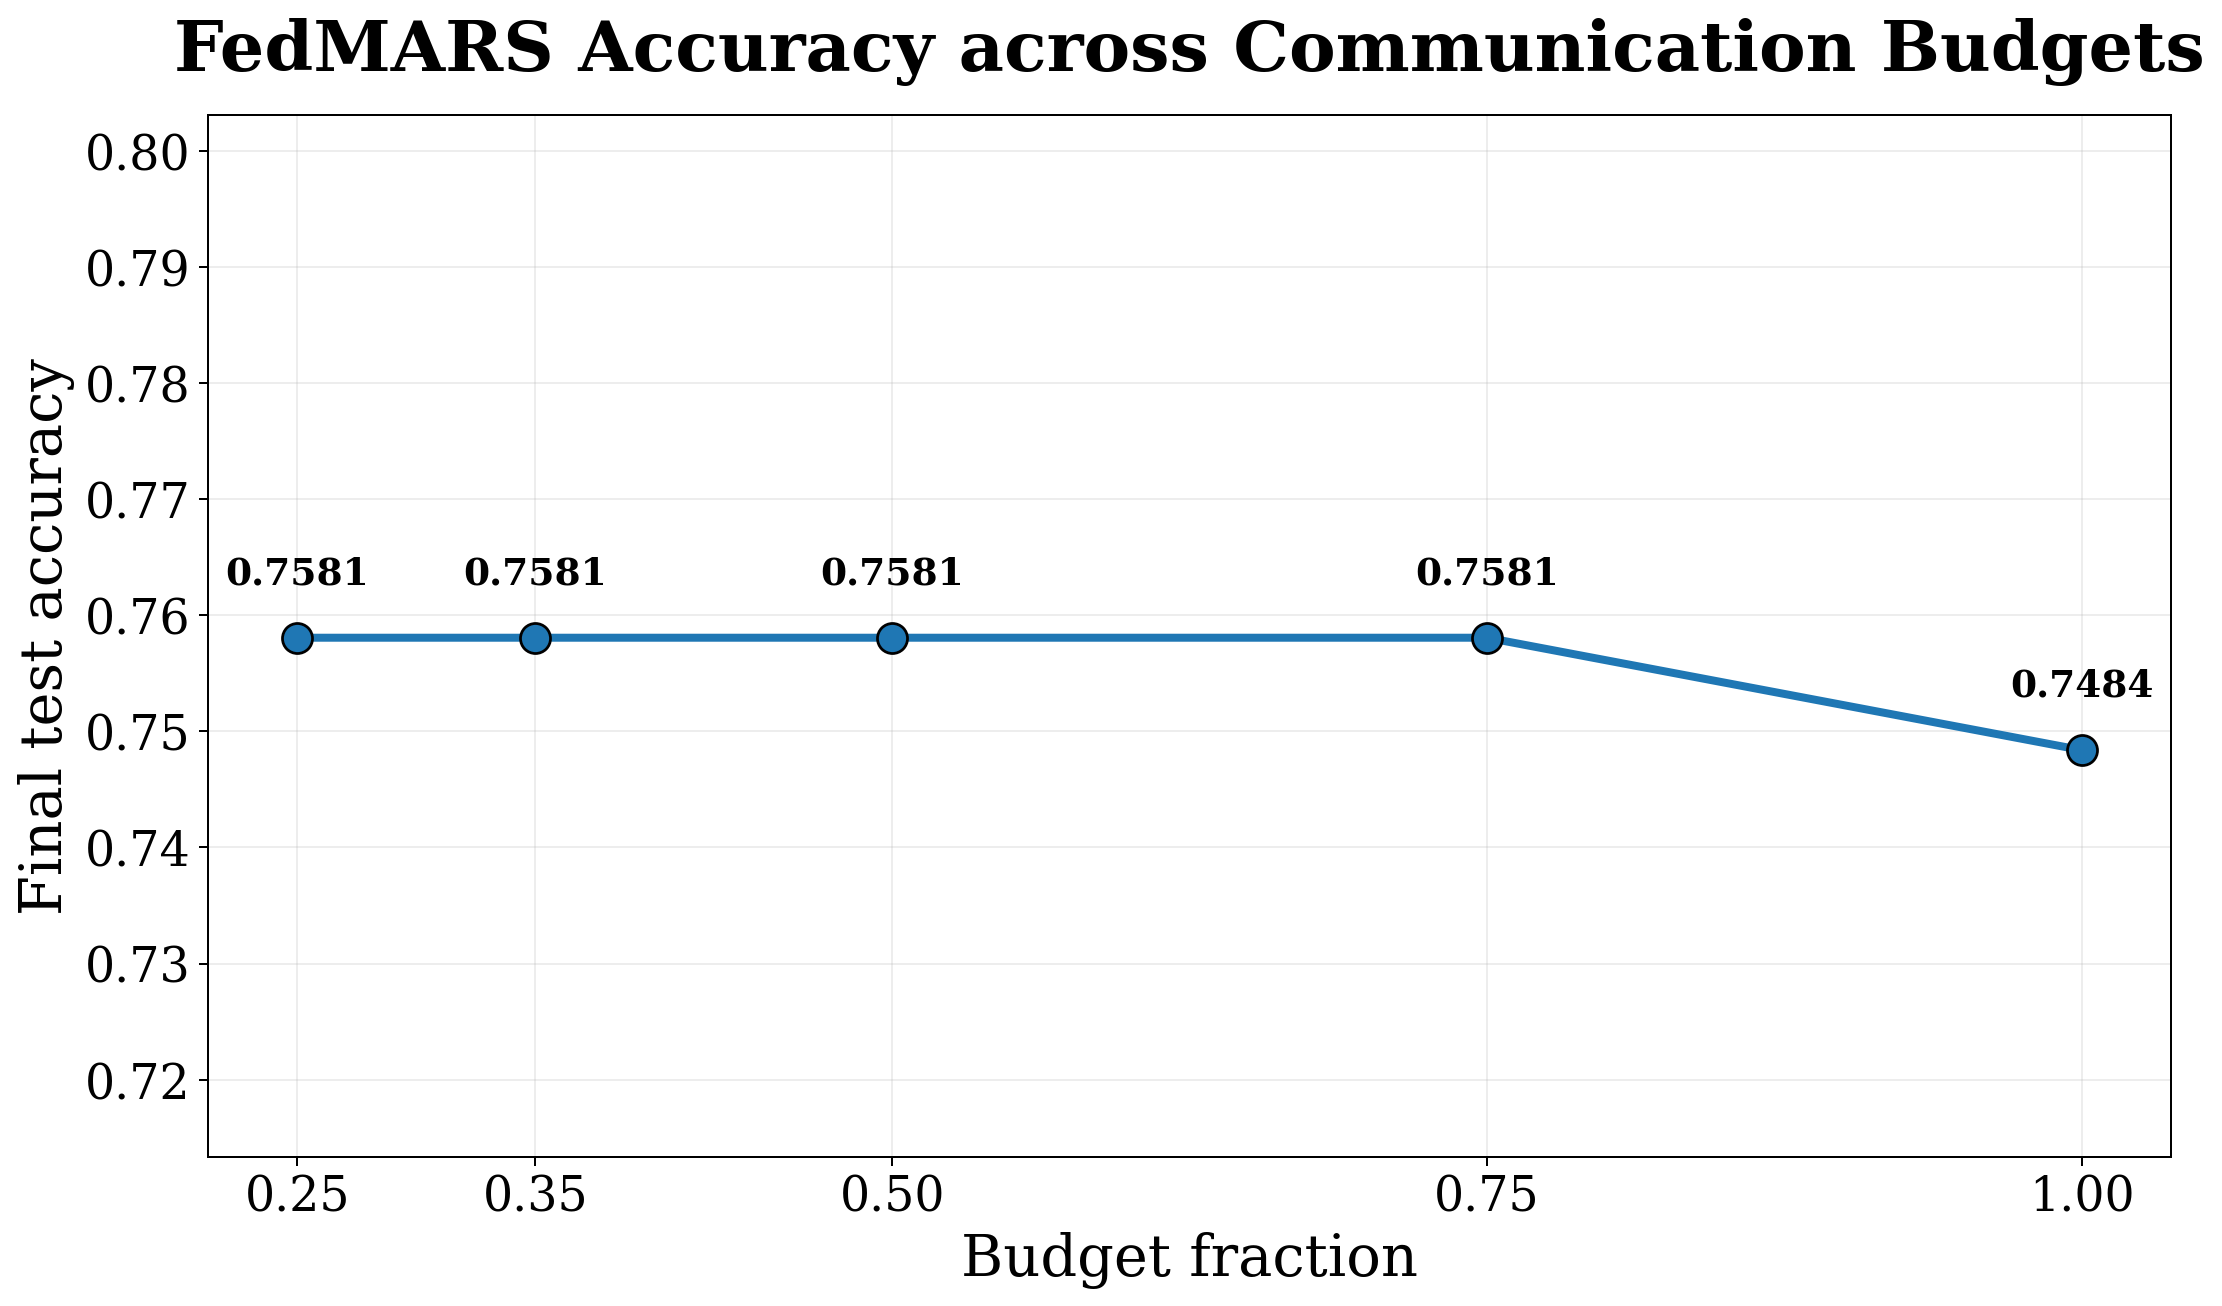

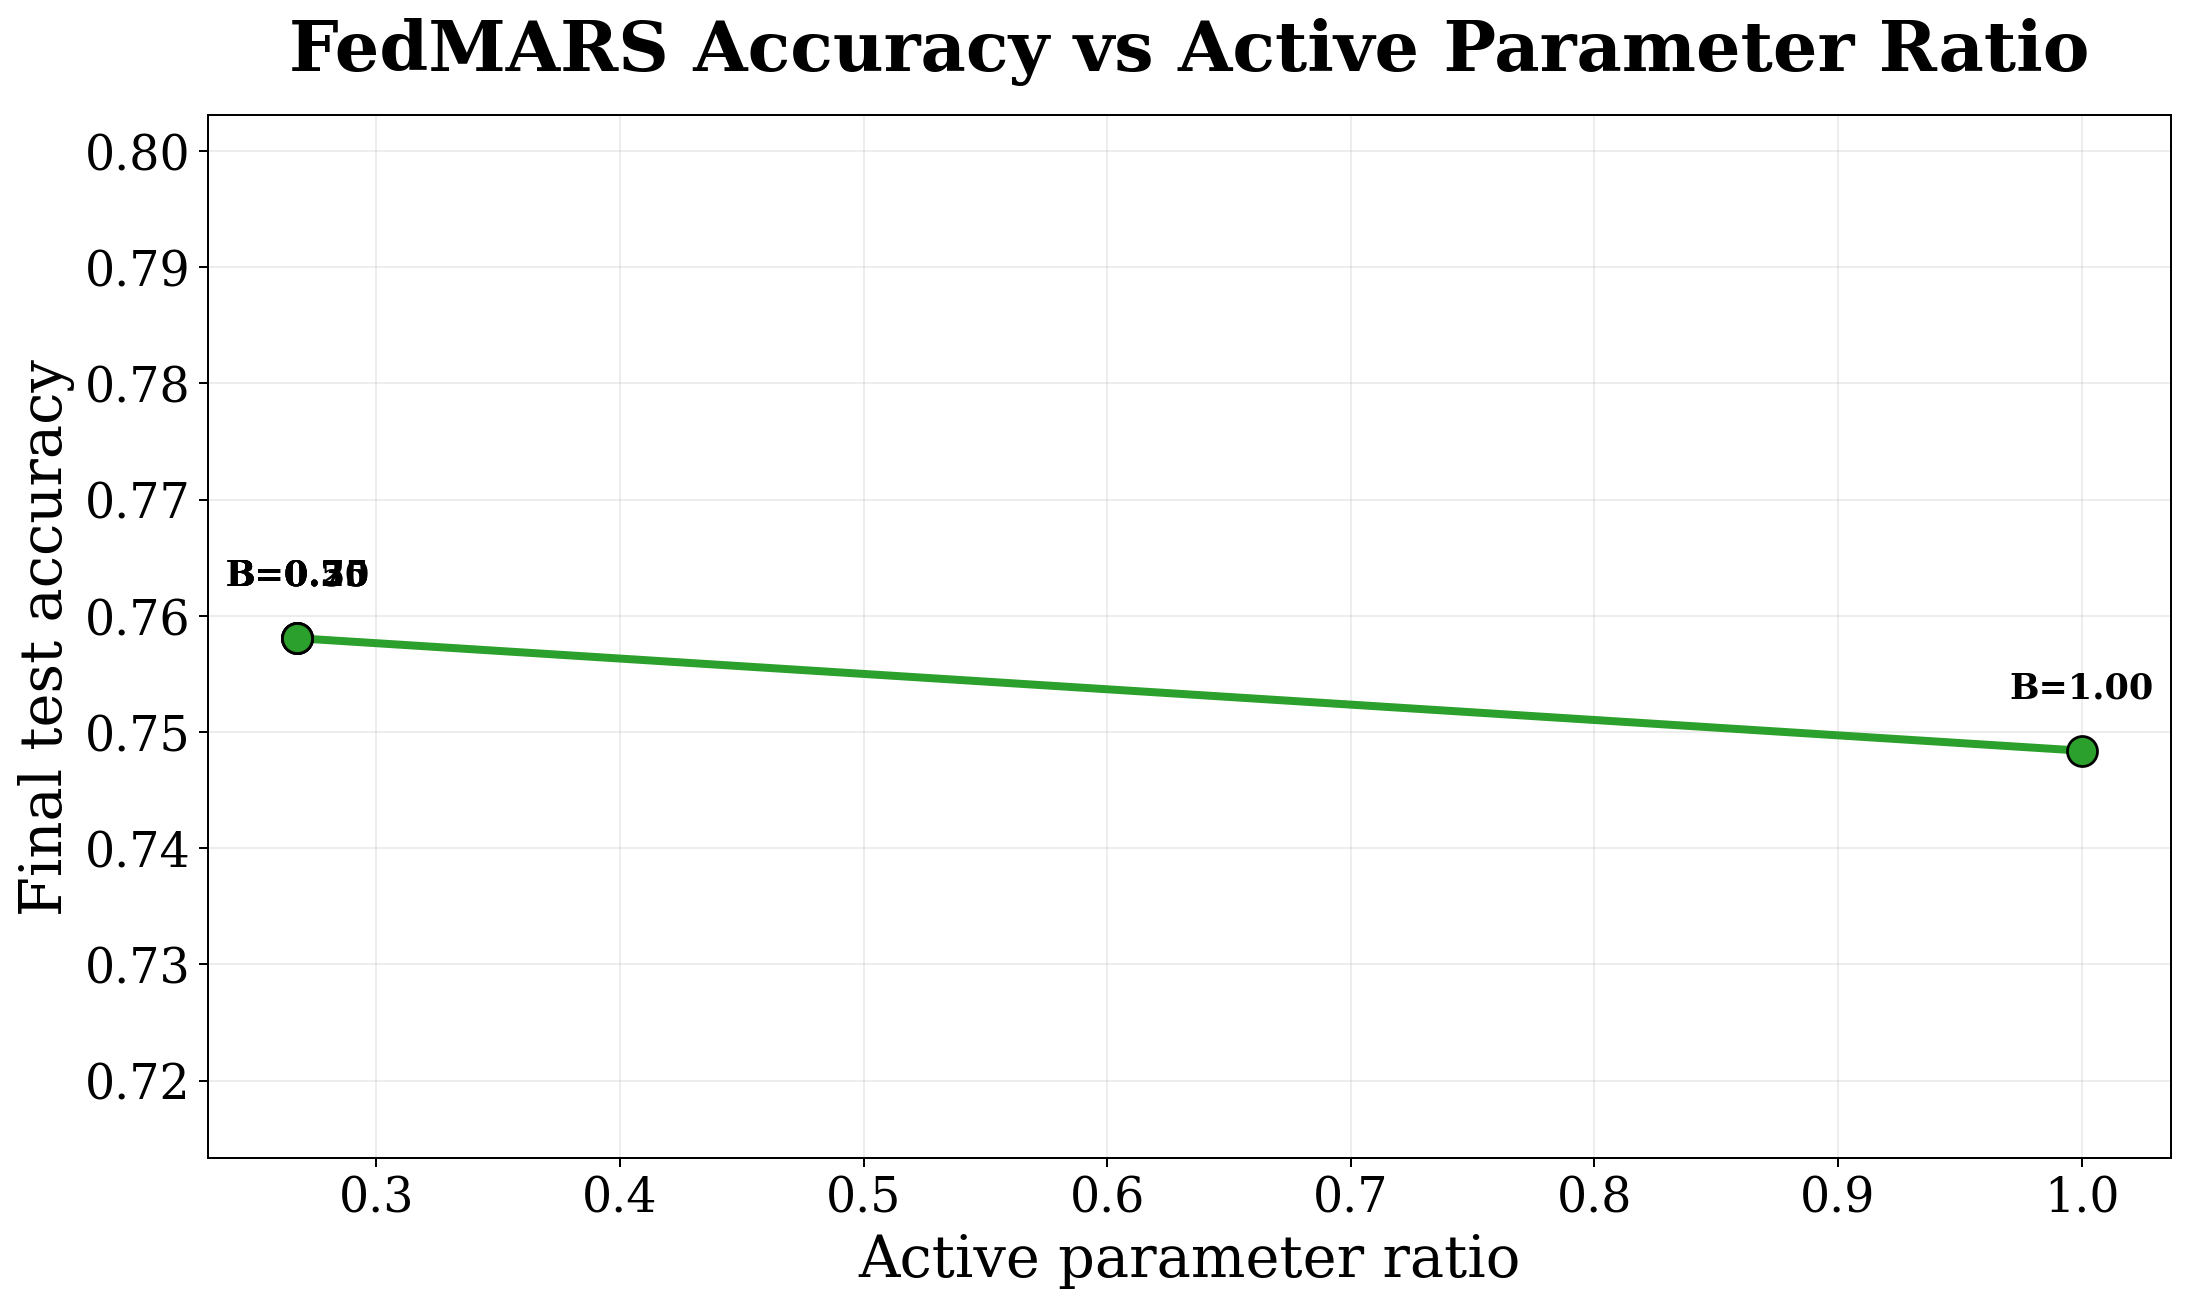

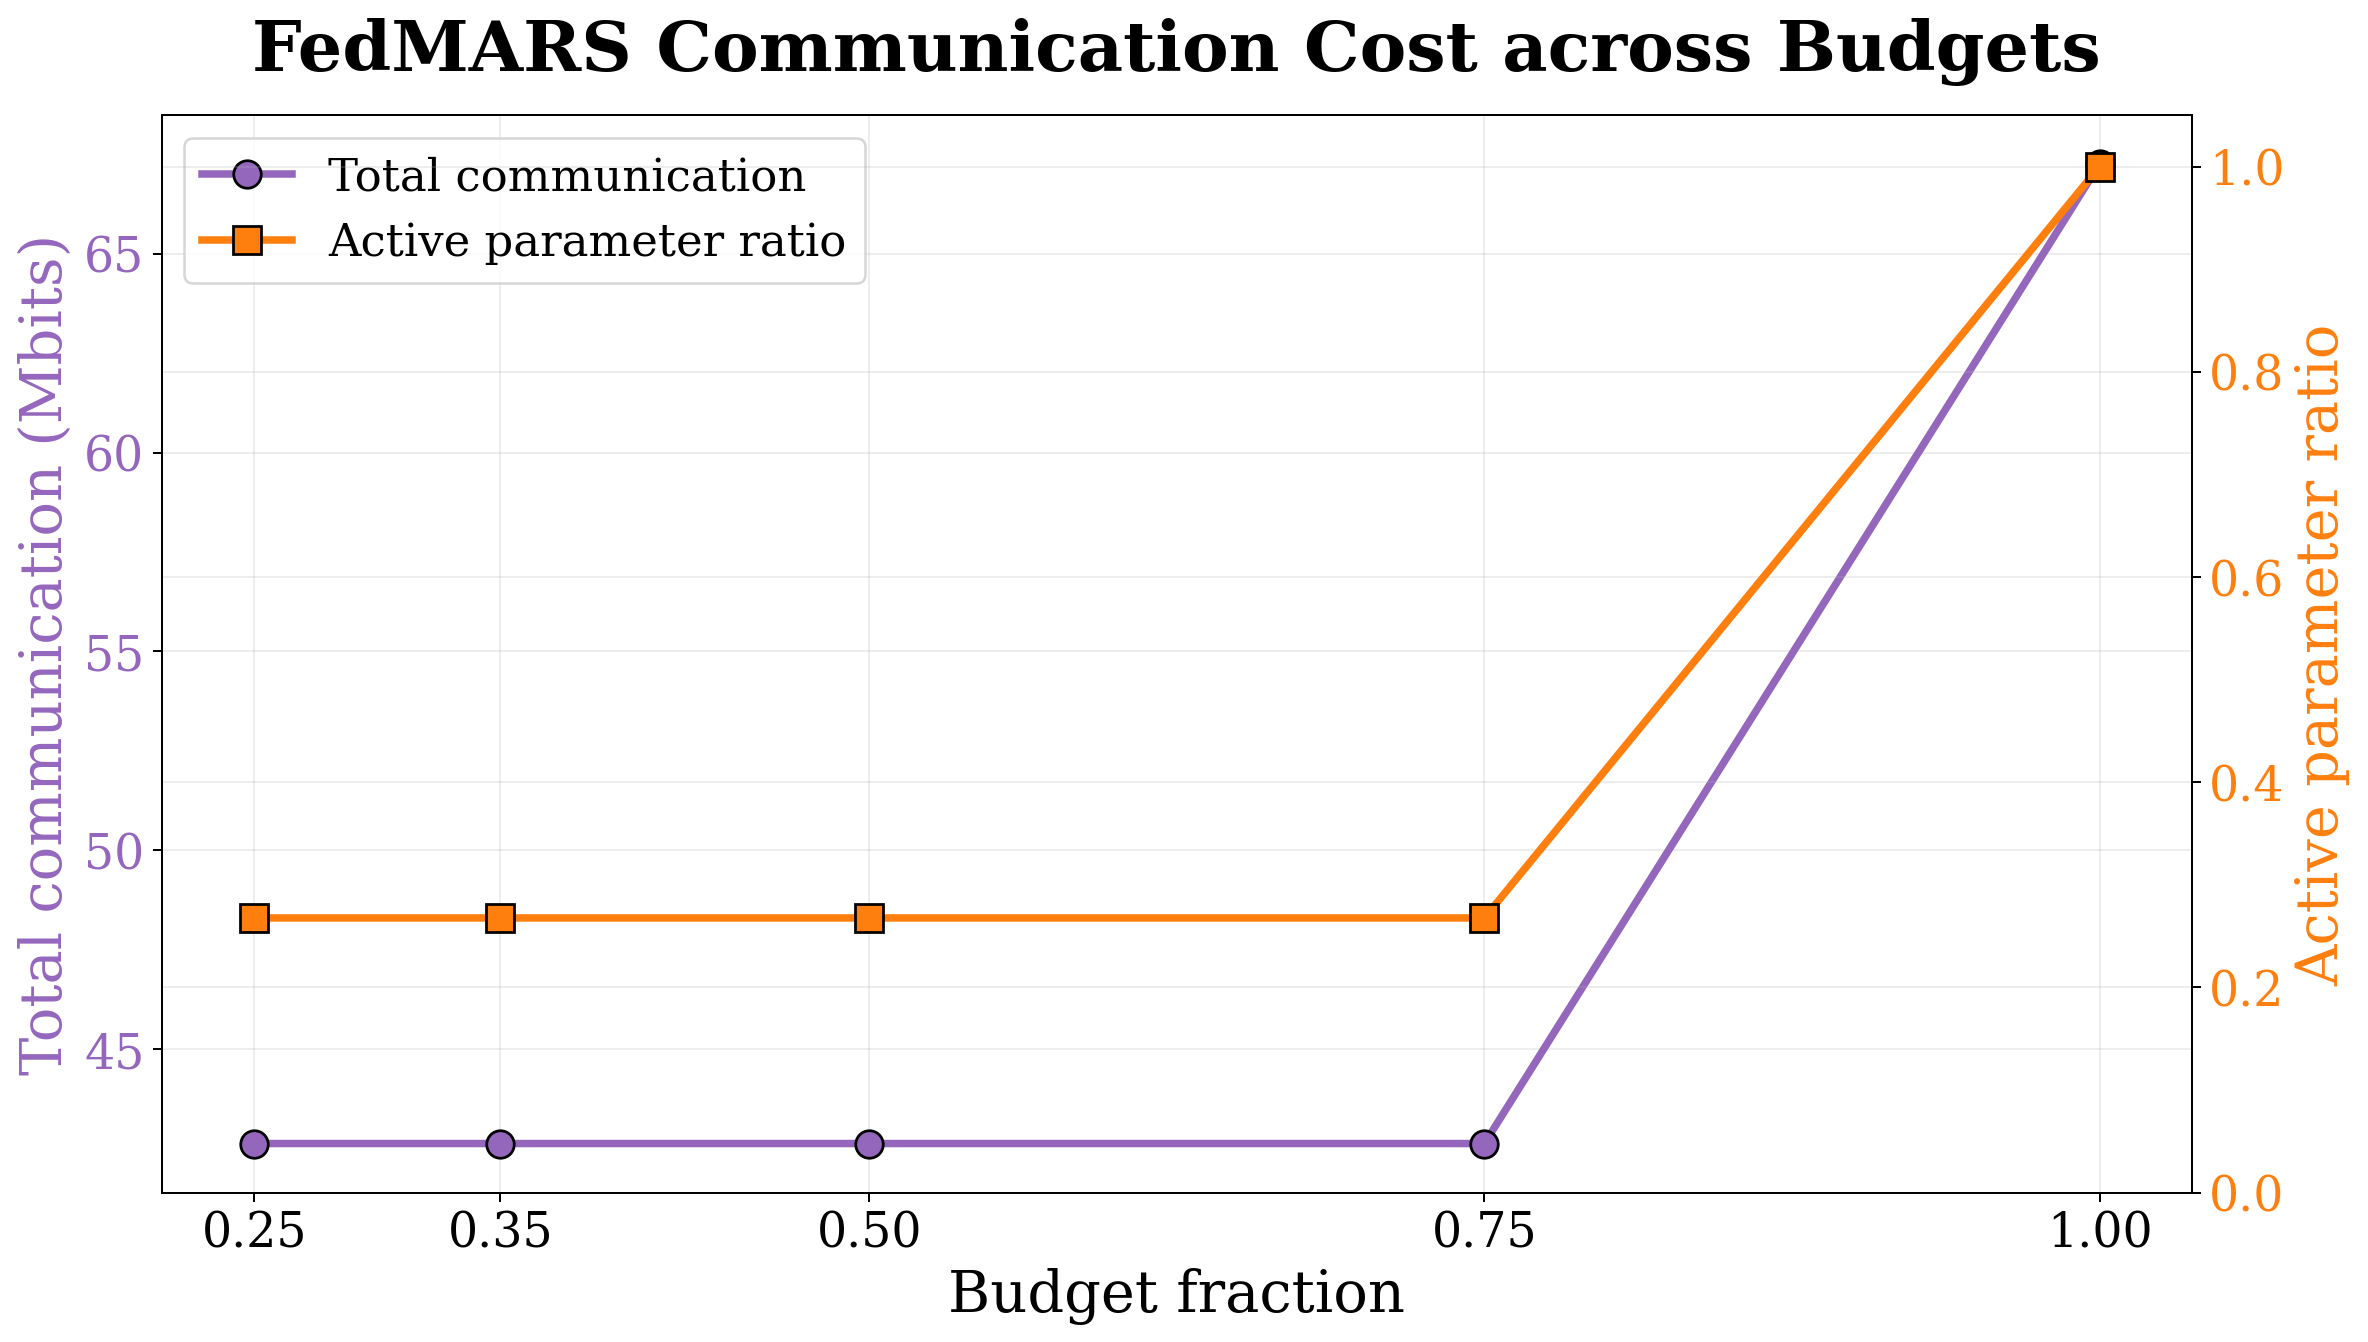

## Saved files

,Saved files
0,A5_fedmars_accuracy_across_budgets.pdf
1,A5_fedmars_accuracy_across_budgets.png
2,A5_fedmars_accuracy_across_budgets.svg
3,A5_fedmars_accuracy_vs_active_parameter_ratio.pdf
4,A5_fedmars_accuracy_vs_active_parameter_ratio.png
5,A5_fedmars_accuracy_vs_active_parameter_ratio.svg
6,A5_fedmars_communication_cost_across_budgets.pdf
7,A5_fedmars_communication_cost_across_budgets.png
8,A5_fedmars_communication_cost_across_budgets.svg
9,table_A5_1_fedmars_budget_sensitivity.csv


In [4]:
from IPython.display import display, Markdown

VALIDATION_NAME = "Validation 5: FedMARS Budget Sensitivity"
BUDGET_UCI_ID = 212
BUDGET_DATASET_NAME = "Vertebral Column"
BUDGET_ALPHA = 0.1
BUDGET_LOCAL_EPOCHS = 5
BUDGET_FRACTIONS = [0.25, 0.35, 0.50, 0.75, 1.00]
METHOD_ORDER = ["FedMARS"]

setup_table = pd.DataFrame([
    ["Validation name", VALIDATION_NAME],
    ["Dataset", BUDGET_DATASET_NAME],
    ["UCI ID", BUDGET_UCI_ID],
    ["Method", "FedMARS"],
    ["Budget fractions", str(BUDGET_FRACTIONS)],
    ["Alpha", BUDGET_ALPHA],
    ["Local epochs", BUDGET_LOCAL_EPOCHS],
    ["Rounds", NUM_ROUNDS],
    ["Seeds", len(EXPERIMENT_SEEDS)],
    ["Clients", DEFAULT_NUM_CLIENTS],
    ["Client fraction", CLIENT_FRACTION],
    ["Batch size", LOCAL_BATCH_SIZE],
    ["Local learning rate", LOCAL_LR],
    ["Weight decay", WEIGHT_DECAY],
], columns=["Item", "Value"])

display(Markdown("# Validation 5: FedMARS Budget Sensitivity"))
display(Markdown("## Experimental setup"))
display(setup_table)

all_budget_runs = []
all_budget_curves = []
all_budget_summaries = []

for budget_fraction in BUDGET_FRACTIONS:
    COMM_BUDGET_FRACTION = float(budget_fraction)
    display(Markdown(f"## Running FedMARS with budget fraction = {budget_fraction:.2f}"))
    run_df, curve_df, dataset_info = run_single_condition(
        uci_id=int(BUDGET_UCI_ID),
        alpha=float(BUDGET_ALPHA),
        local_epochs=int(BUDGET_LOCAL_EPOCHS),
    )
    run_df.insert(0, "budget_fraction", float(budget_fraction))
    run_df.insert(1, "uci_id", int(BUDGET_UCI_ID))
    run_df.insert(2, "dataset_name", BUDGET_DATASET_NAME)
    curve_df.insert(0, "budget_fraction", float(budget_fraction))
    curve_df.insert(1, "uci_id", int(BUDGET_UCI_ID))
    curve_df.insert(2, "dataset_name", BUDGET_DATASET_NAME)

    summary_df = summarize_validation3(run_df, curve_df)
    summary_df.insert(0, "budget_fraction", float(budget_fraction))
    summary_df.insert(1, "uci_id", int(BUDGET_UCI_ID))
    summary_df.insert(2, "dataset_name", BUDGET_DATASET_NAME)

    all_budget_runs.append(run_df)
    all_budget_curves.append(curve_df)
    all_budget_summaries.append(summary_df)

budget_run_df = pd.concat(all_budget_runs, ignore_index=True)
budget_curve_df = pd.concat(all_budget_curves, ignore_index=True)
fedmars_budget_df = pd.concat(all_budget_summaries, ignore_index=True)

fedmars_budget_df = fedmars_budget_df[fedmars_budget_df["method"] == "FedMARS"].copy()
fedmars_budget_df = fedmars_budget_df[fedmars_budget_df["budget_fraction"].isin(BUDGET_FRACTIONS)].copy()
fedmars_budget_df = fedmars_budget_df.sort_values("budget_fraction").reset_index(drop=True)
fedmars_budget_df["total_mbits"] = fedmars_budget_df["total_bits_mean"] / 1e6
fedmars_budget_df["client_to_server_mbits"] = fedmars_budget_df["client_to_server_bits_mean"] / 1e6

full_row = fedmars_budget_df.iloc[(fedmars_budget_df["budget_fraction"] - 1.00).abs().argsort()[:1]]
full_comm = float(full_row["total_mbits"].iloc[0])
fedmars_budget_df["communication_saving_vs_full"] = 100.0 * (1.0 - fedmars_budget_df["total_mbits"] / max(full_comm, 1e-12))

budget_run_df.to_csv("validation5_fedmars_budget_raw_runs.csv", index=False)
budget_curve_df.to_csv("validation5_fedmars_budget_curve_history.csv", index=False)
fedmars_budget_df.to_csv("validation5_fedmars_budget_summary.csv", index=False)

summary_table = fedmars_budget_df[[
    "budget_fraction",
    "final_test_accuracy_mean",
    "final_test_accuracy_std",
    "shared_budget_accuracy_mean",
    "shared_budget_accuracy_std",
    "total_mbits",
    "mean_selected_layer_ratio",
    "mean_active_parameter_ratio",
    "communication_saving_vs_full",
]].copy()

summary_table.columns = [
    "Budget fraction",
    "Final test accuracy",
    "Seed std.",
    "Shared-budget accuracy",
    "Shared-budget std.",
    "Total communication (Mbits)",
    "Selected layer ratio",
    "Active parameter ratio",
    "Communication saving vs full (%)",
]

display(Markdown("## Table A5-1. FedMARS budget sensitivity summary"))
display(summary_table.style.format({
    "Budget fraction": "{:.2f}",
    "Final test accuracy": "{:.4f}",
    "Seed std.": "{:.4f}",
    "Shared-budget accuracy": "{:.4f}",
    "Shared-budget std.": "{:.4f}",
    "Total communication (Mbits)": "{:.4f}",
    "Selected layer ratio": "{:.4f}",
    "Active parameter ratio": "{:.4f}",
    "Communication saving vs full (%)": "{:.2f}",
}))
summary_table.to_csv("table_A5_1_fedmars_budget_sensitivity.csv", index=False)

best_sparse = fedmars_budget_df[fedmars_budget_df["budget_fraction"] < 1.0].sort_values(
    ["final_test_accuracy_mean", "communication_saving_vs_full"], ascending=[False, False]
).head(1)
full_budget = fedmars_budget_df.iloc[(fedmars_budget_df["budget_fraction"] - 1.00).abs().argsort()[:1]]
comparison_table = pd.concat([
    pd.DataFrame([{
        "Setting": "Best sparse FedMARS",
        "Budget fraction": float(best_sparse["budget_fraction"].iloc[0]),
        "Final test accuracy": float(best_sparse["final_test_accuracy_mean"].iloc[0]),
        "Total communication (Mbits)": float(best_sparse["total_mbits"].iloc[0]),
        "Active parameter ratio": float(best_sparse["mean_active_parameter_ratio"].iloc[0]),
        "Communication saving vs full (%)": float(best_sparse["communication_saving_vs_full"].iloc[0]),
    }]),
    pd.DataFrame([{
        "Setting": "Full-budget FedMARS",
        "Budget fraction": float(full_budget["budget_fraction"].iloc[0]),
        "Final test accuracy": float(full_budget["final_test_accuracy_mean"].iloc[0]),
        "Total communication (Mbits)": float(full_budget["total_mbits"].iloc[0]),
        "Active parameter ratio": float(full_budget["mean_active_parameter_ratio"].iloc[0]),
        "Communication saving vs full (%)": float(full_budget["communication_saving_vs_full"].iloc[0]),
    }]),
], ignore_index=True)

display(Markdown("## Table A5-2. Best sparse FedMARS versus full-budget FedMARS"))
display(comparison_table.style.format({
    "Budget fraction": "{:.2f}",
    "Final test accuracy": "{:.4f}",
    "Total communication (Mbits)": "{:.4f}",
    "Active parameter ratio": "{:.4f}",
    "Communication saving vs full (%)": "{:.2f}",
}))
comparison_table.to_csv("table_A5_2_sparse_vs_full_budget.csv", index=False)

plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "font.family": "serif",
    "font.size": 18,
    "axes.titlesize": 28,
    "axes.labelsize": 23,
    "xtick.labelsize": 19,
    "ytick.labelsize": 19,
    "legend.fontsize": 18,
    "axes.grid": True,
    "grid.alpha": 0.22,
})

fm = fedmars_budget_df.copy()

fig, ax = plt.subplots(figsize=(12.5, 7.6))
ax.plot(
    fm["budget_fraction"],
    fm["final_test_accuracy_mean"],
    marker="o",
    markersize=12,
    linewidth=3.2,
    color="#1f77b4",
    markeredgecolor="black",
    markeredgewidth=1.1,
)
for _, r in fm.iterrows():
    ax.text(r["budget_fraction"], r["final_test_accuracy_mean"] + 0.004, f"{r['final_test_accuracy_mean']:.4f}", ha="center", va="bottom", fontsize=15, fontweight="bold")
ax.set_title("FedMARS Accuracy across Communication Budgets", fontweight="bold", pad=18)
ax.set_xlabel("Budget fraction")
ax.set_ylabel("Final test accuracy")
ax.set_xticks(BUDGET_FRACTIONS)
ax.set_ylim(max(0.0, fm["final_test_accuracy_mean"].min() - 0.035), min(1.0, fm["final_test_accuracy_mean"].max() + 0.045))
ax.grid(True, alpha=0.22)
fig.tight_layout()
plt.savefig("A5_fedmars_accuracy_across_budgets.png", dpi=600, bbox_inches="tight")
plt.savefig("A5_fedmars_accuracy_across_budgets.pdf", bbox_inches="tight")
plt.savefig("A5_fedmars_accuracy_across_budgets.svg", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12.5, 7.6))
ax.plot(
    fm["mean_active_parameter_ratio"],
    fm["final_test_accuracy_mean"],
    marker="o",
    markersize=12,
    linewidth=3.2,
    color="#2ca02c",
    markeredgecolor="black",
    markeredgewidth=1.1,
)
for _, r in fm.iterrows():
    ax.text(r["mean_active_parameter_ratio"], r["final_test_accuracy_mean"] + 0.004, f"B={r['budget_fraction']:.2f}", ha="center", va="bottom", fontsize=14, fontweight="bold")
ax.set_title("FedMARS Accuracy vs Active Parameter Ratio", fontweight="bold", pad=18)
ax.set_xlabel("Active parameter ratio")
ax.set_ylabel("Final test accuracy")
ax.set_ylim(max(0.0, fm["final_test_accuracy_mean"].min() - 0.035), min(1.0, fm["final_test_accuracy_mean"].max() + 0.045))
ax.grid(True, alpha=0.22)
fig.tight_layout()
plt.savefig("A5_fedmars_accuracy_vs_active_parameter_ratio.png", dpi=600, bbox_inches="tight")
plt.savefig("A5_fedmars_accuracy_vs_active_parameter_ratio.pdf", bbox_inches="tight")
plt.savefig("A5_fedmars_accuracy_vs_active_parameter_ratio.svg", bbox_inches="tight")
plt.show()

fig, ax1 = plt.subplots(figsize=(13.5, 7.8))
ax1.plot(
    fm["budget_fraction"],
    fm["total_mbits"],
    marker="o",
    markersize=11,
    linewidth=3.0,
    color="#9467bd",
    markeredgecolor="black",
    markeredgewidth=1.1,
    label="Total communication",
)
ax1.set_xlabel("Budget fraction")
ax1.set_ylabel("Total communication (Mbits)", color="#9467bd")
ax1.tick_params(axis="y", labelcolor="#9467bd")
ax1.set_xticks(BUDGET_FRACTIONS)
ax2 = ax1.twinx()
ax2.plot(
    fm["budget_fraction"],
    fm["mean_active_parameter_ratio"],
    marker="s",
    markersize=11,
    linewidth=3.0,
    color="#ff7f0e",
    markeredgecolor="black",
    markeredgewidth=1.1,
    label="Active parameter ratio",
)
ax2.set_ylabel("Active parameter ratio", color="#ff7f0e")
ax2.tick_params(axis="y", labelcolor="#ff7f0e")
ax2.set_ylim(0.0, 1.05)
ax1.set_title("FedMARS Communication Cost across Budgets", fontweight="bold", pad=18)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)
ax1.grid(True, alpha=0.22)
fig.tight_layout()
plt.savefig("A5_fedmars_communication_cost_across_budgets.png", dpi=600, bbox_inches="tight")
plt.savefig("A5_fedmars_communication_cost_across_budgets.pdf", bbox_inches="tight")
plt.savefig("A5_fedmars_communication_cost_across_budgets.svg", bbox_inches="tight")
plt.show()

saved_outputs = sorted([
    f for f in os.listdir(".")
    if f.startswith("validation5_fedmars") or f.startswith("table_A5") or f.startswith("A5_fedmars")
])
display(Markdown("## Saved files"))
display(pd.DataFrame({"Saved files": saved_outputs}))


# Plot-only FedMARS budget sensitivity

,budget_fraction,final_test_accuracy_mean,final_test_accuracy_std,total_mbits,mean_selected_layer_ratio,mean_active_parameter_ratio
0,0.25,0.7581,0.0593,42.6240,0.6917,0.2676
1,0.35,0.7581,0.0593,42.6240,0.6917,0.2676
2,0.50,0.7581,0.0593,42.6240,0.6917,0.2676
3,0.75,0.7581,0.0593,42.6240,0.6917,0.2676
4,1.00,0.7484,0.0690,67.2512,1.0000,1.0000


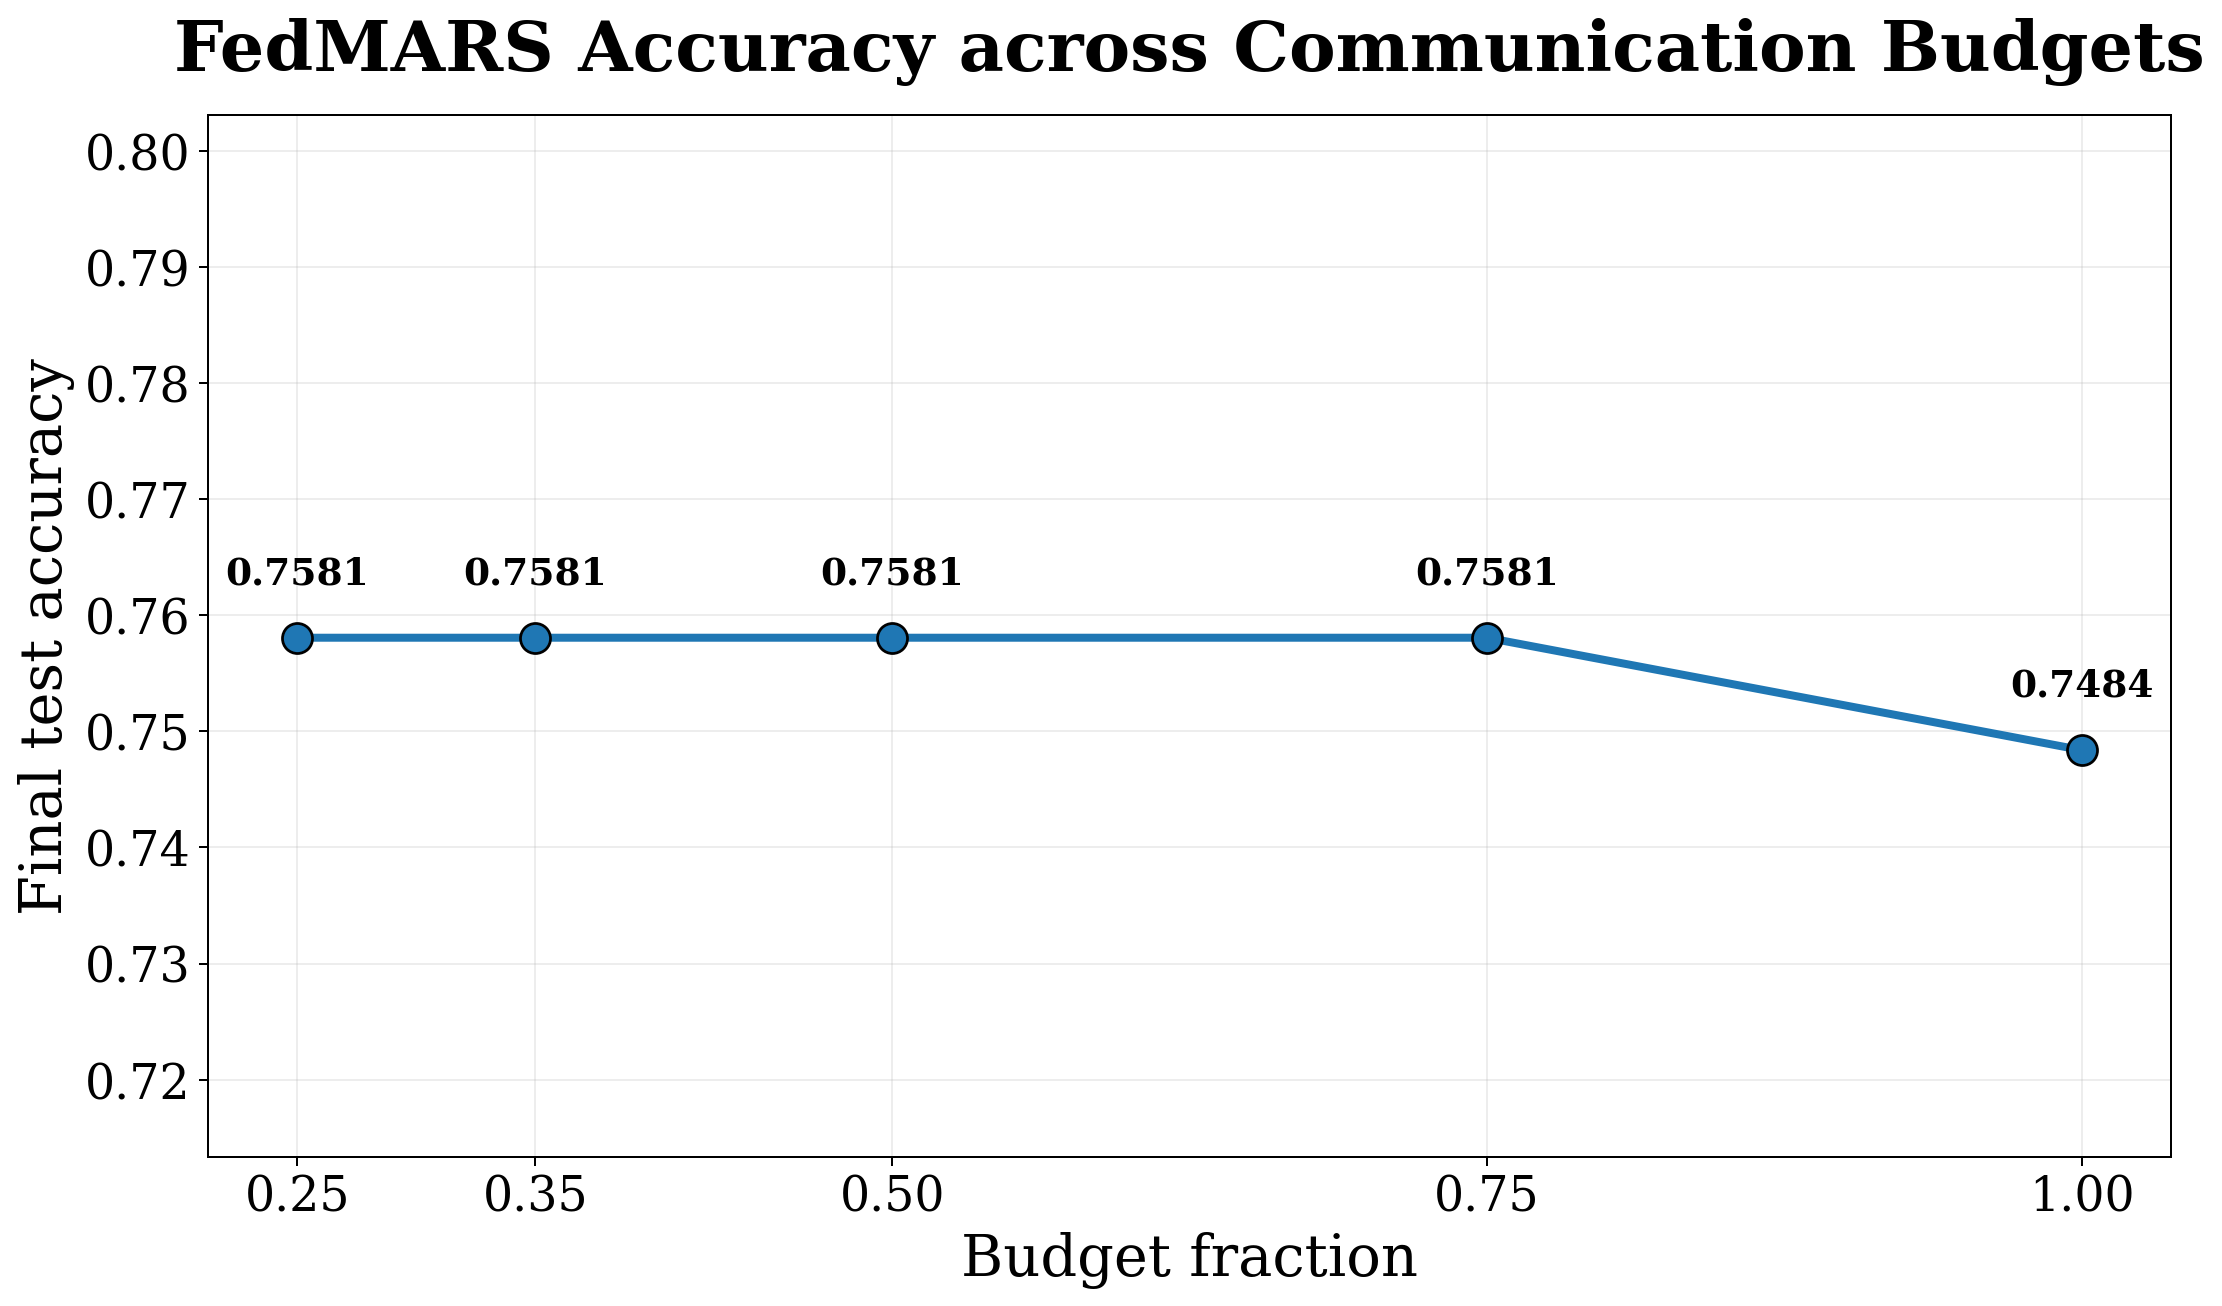

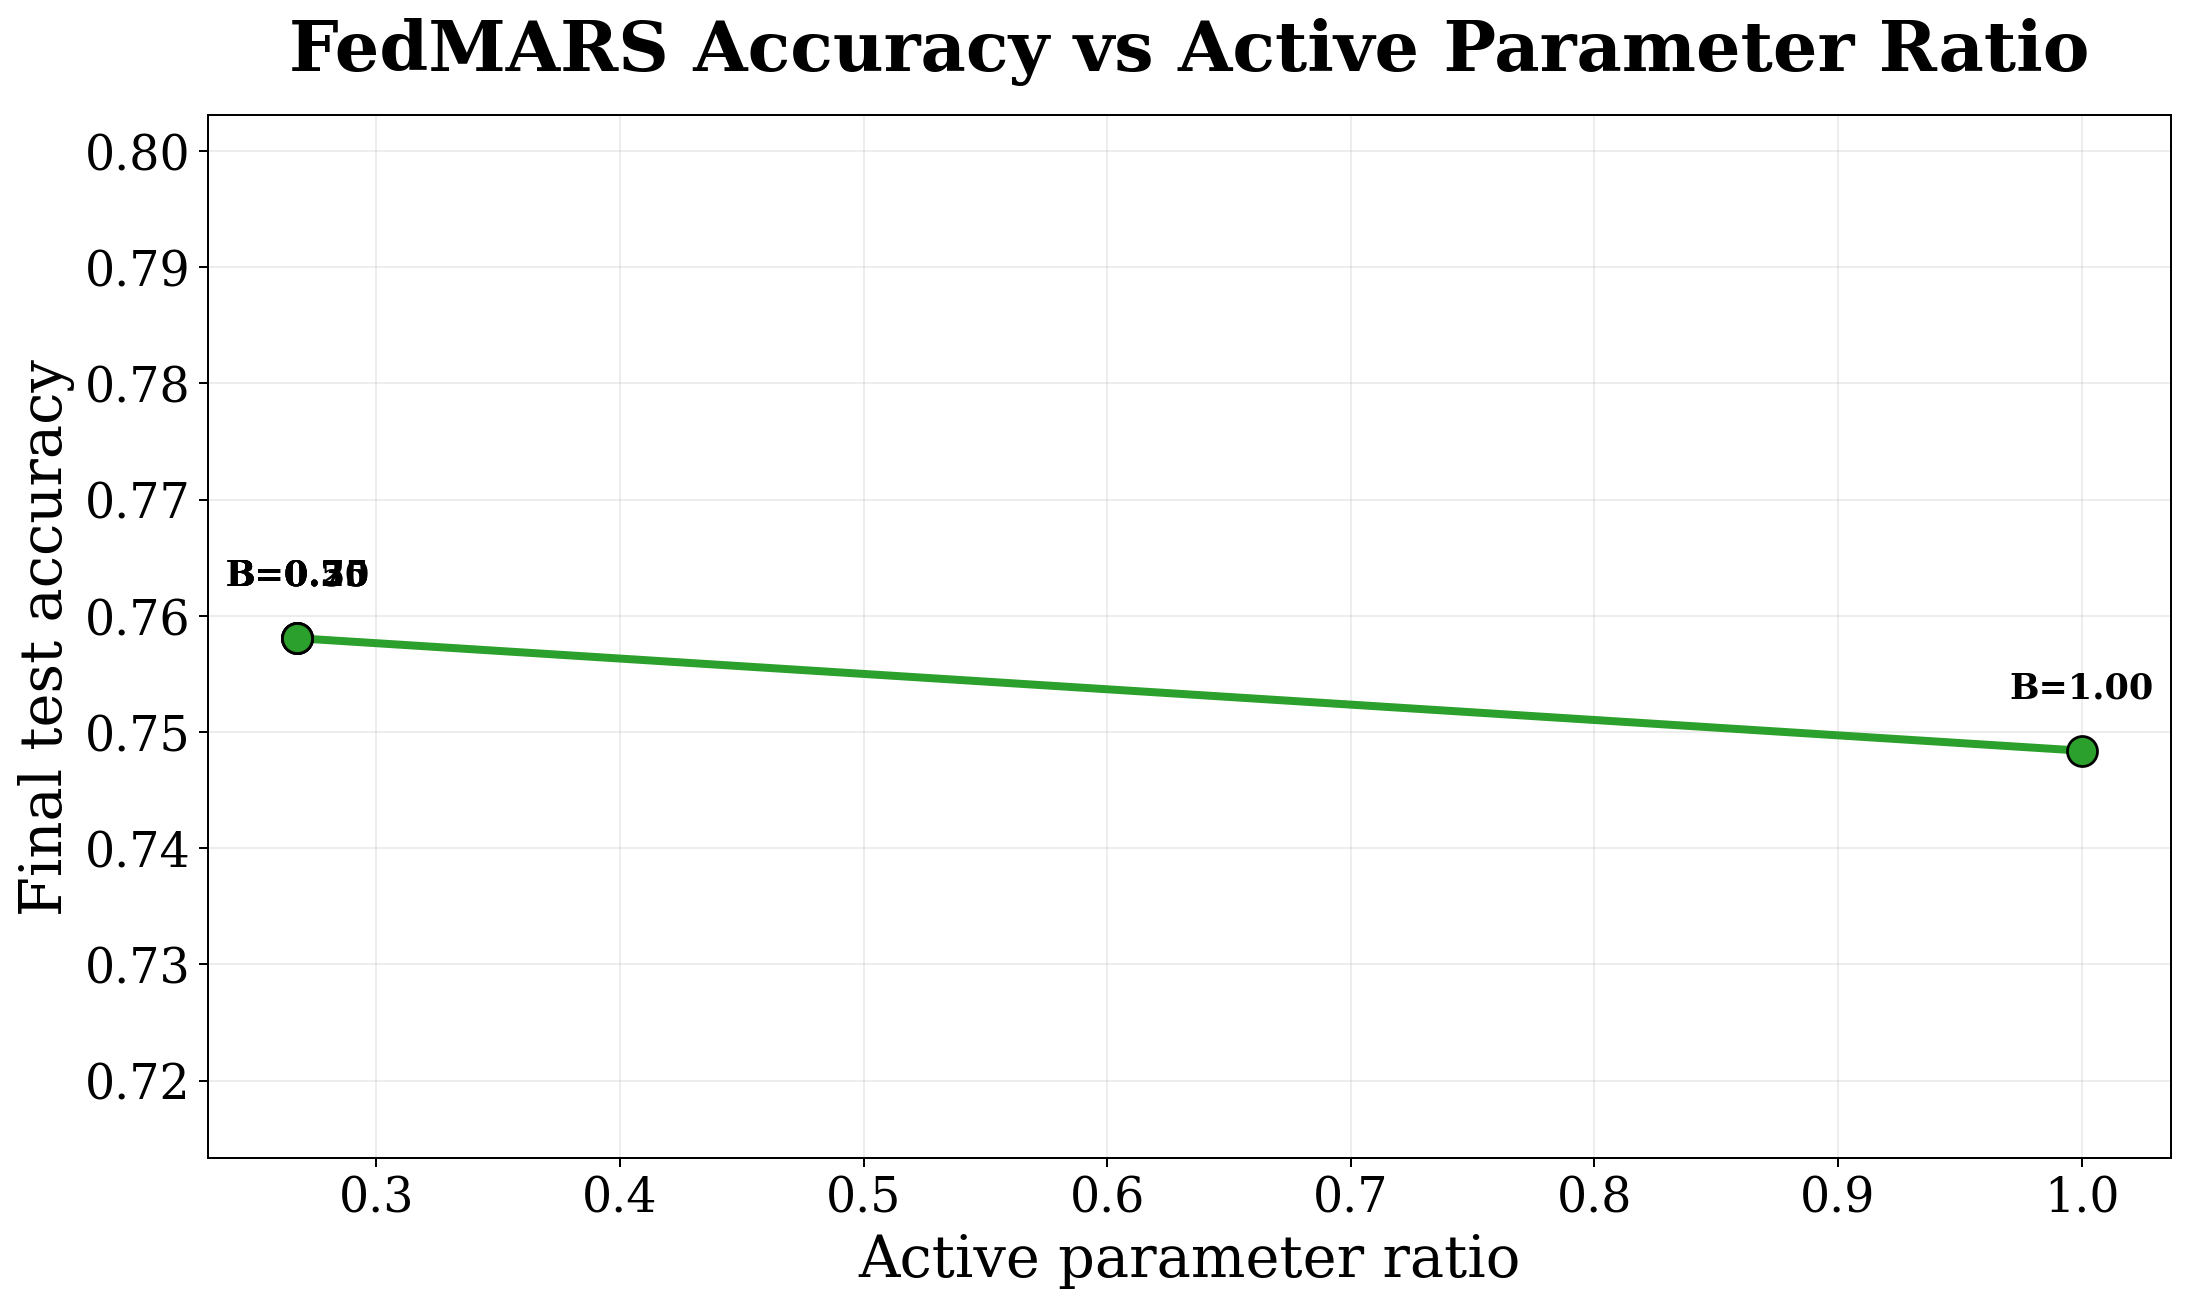

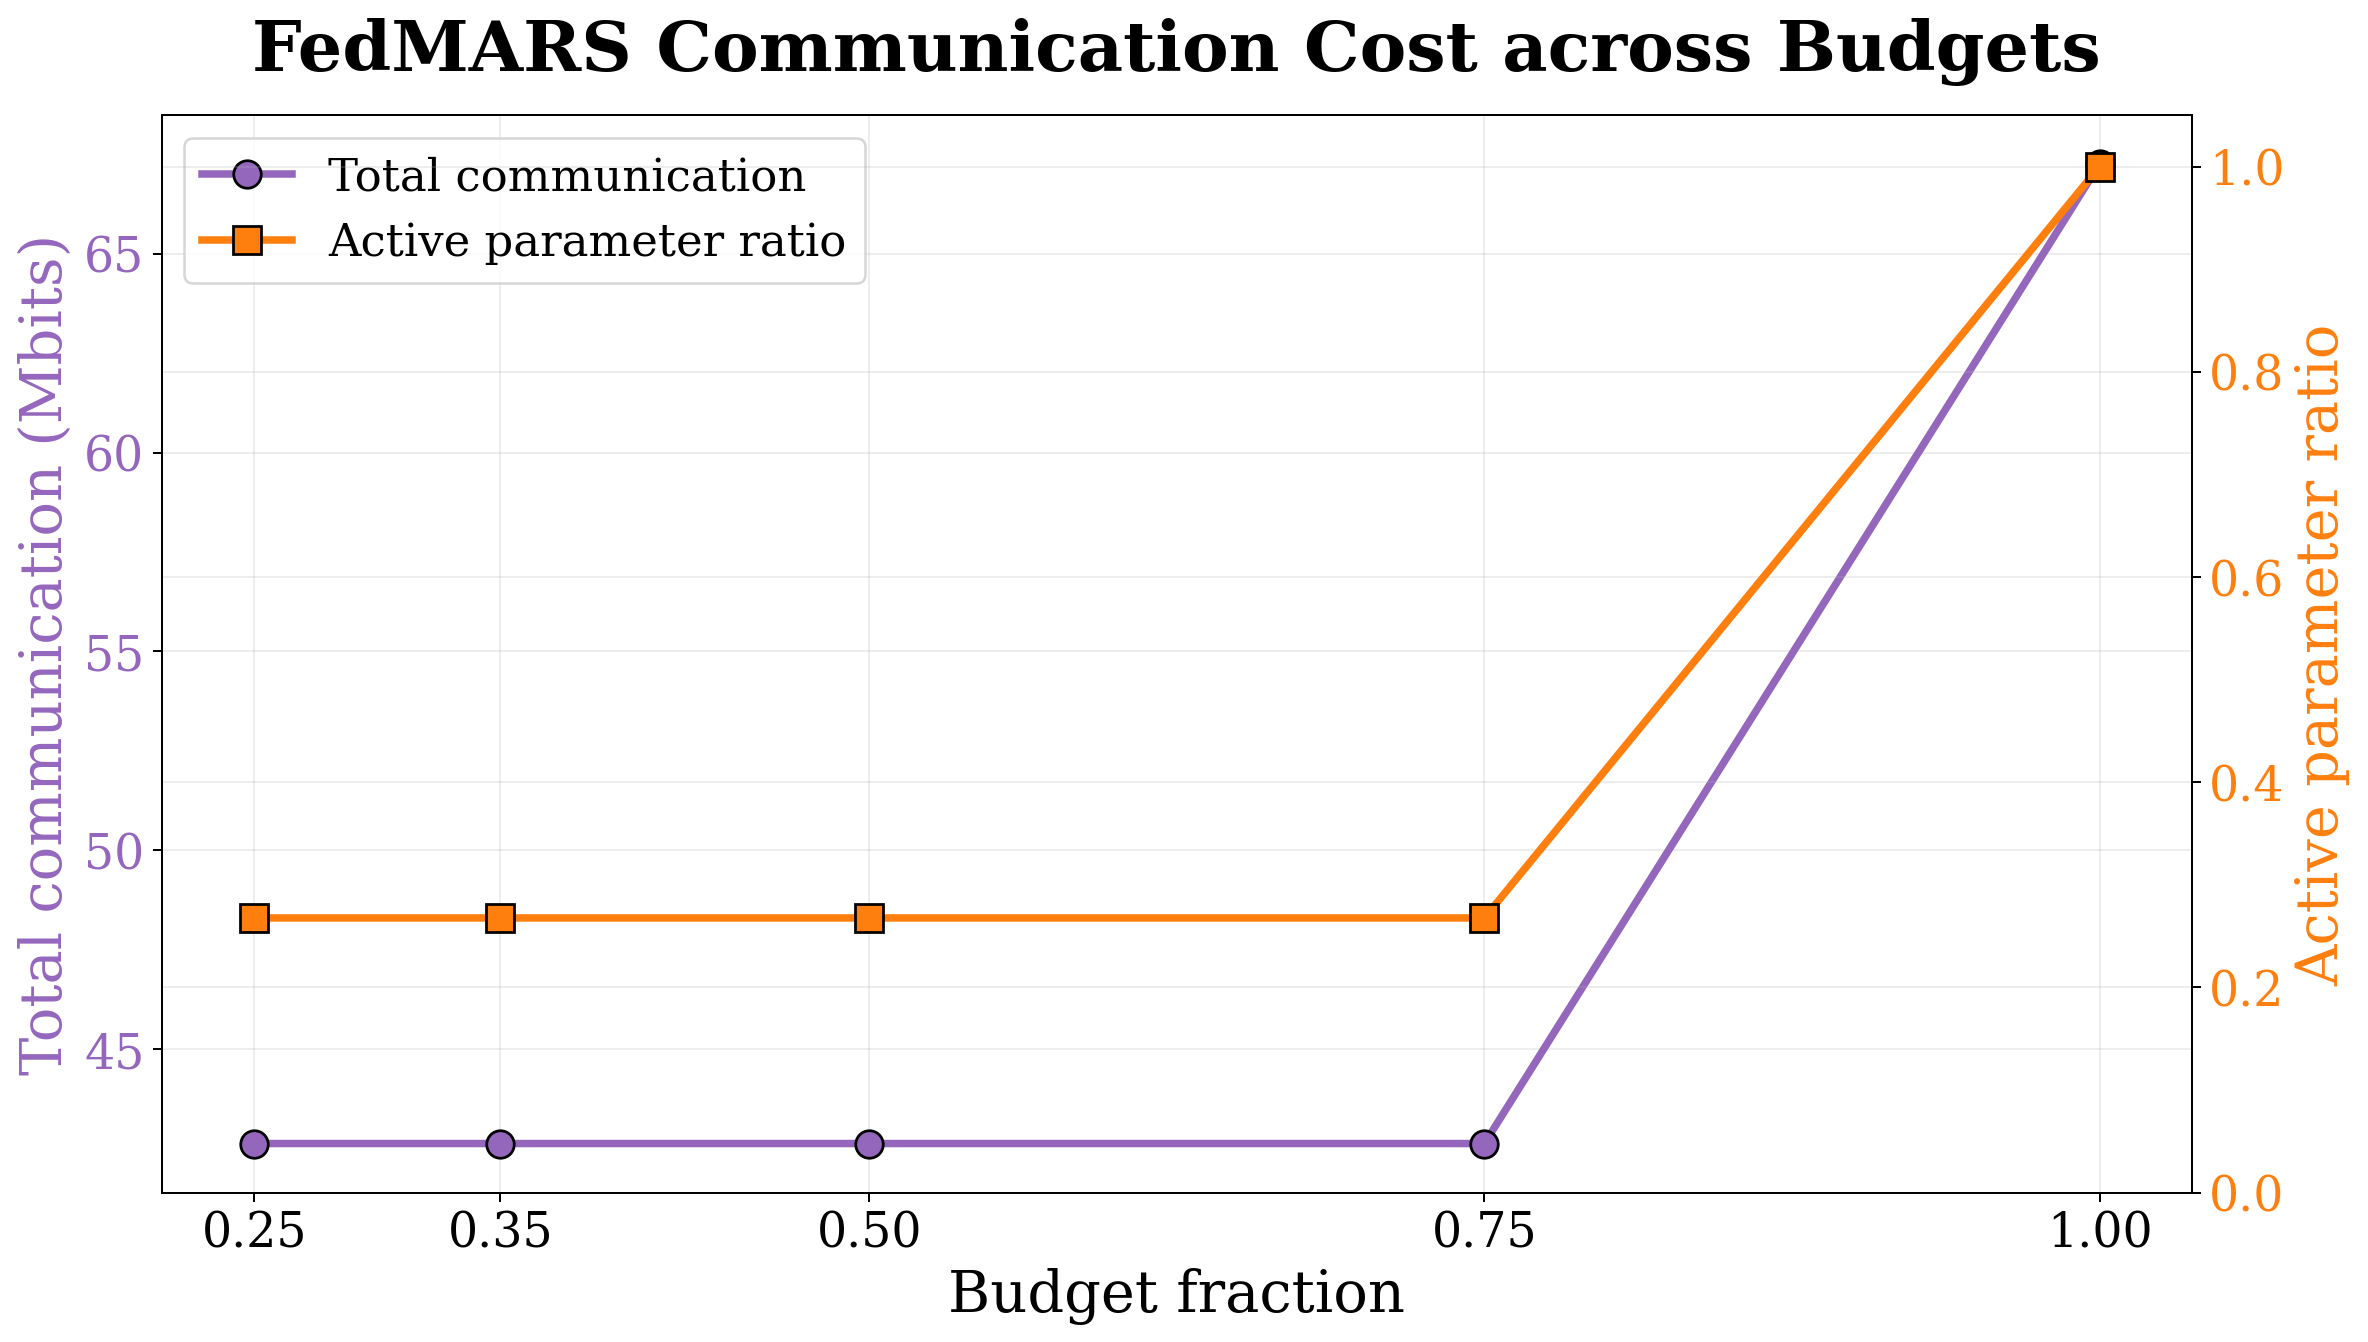

In [6]:
RUN_PLOT_ONLY = True

if RUN_PLOT_ONLY:
    from IPython.display import display, Markdown
    BUDGET_FRACTIONS = [0.25, 0.35, 0.50, 0.75, 1.00]
    fedmars_budget_df = pd.read_csv("validation5_fedmars_budget_summary.csv")
    fedmars_budget_df = fedmars_budget_df[fedmars_budget_df["budget_fraction"].isin(BUDGET_FRACTIONS)].copy()
    fedmars_budget_df = fedmars_budget_df.sort_values("budget_fraction").reset_index(drop=True)
    if "total_mbits" not in fedmars_budget_df.columns:
        fedmars_budget_df["total_mbits"] = fedmars_budget_df["total_bits_mean"] / 1e6

    plt.rcParams.update({
        "figure.dpi": 180,
        "savefig.dpi": 600,
        "font.family": "serif",
        "font.size": 18,
        "axes.titlesize": 28,
        "axes.labelsize": 23,
        "xtick.labelsize": 19,
        "ytick.labelsize": 19,
        "legend.fontsize": 18,
        "axes.grid": True,
        "grid.alpha": 0.22,
    })

    fm = fedmars_budget_df
    display(Markdown("# Plot-only FedMARS budget sensitivity"))
    display(fm[["budget_fraction", "final_test_accuracy_mean", "final_test_accuracy_std", "total_mbits", "mean_selected_layer_ratio", "mean_active_parameter_ratio"]].style.format({
        "budget_fraction": "{:.2f}",
        "final_test_accuracy_mean": "{:.4f}",
        "final_test_accuracy_std": "{:.4f}",
        "total_mbits": "{:.4f}",
        "mean_selected_layer_ratio": "{:.4f}",
        "mean_active_parameter_ratio": "{:.4f}",
    }))

    fig, ax = plt.subplots(figsize=(12.5, 7.6))
    ax.plot(fm["budget_fraction"], fm["final_test_accuracy_mean"], marker="o", markersize=12, linewidth=3.2, color="#1f77b4", markeredgecolor="black", markeredgewidth=1.1)
    for _, r in fm.iterrows():
        ax.text(r["budget_fraction"], r["final_test_accuracy_mean"] + 0.004, f"{r['final_test_accuracy_mean']:.4f}", ha="center", va="bottom", fontsize=15, fontweight="bold")
    ax.set_title("FedMARS Accuracy across Communication Budgets", fontweight="bold", pad=18)
    ax.set_xlabel("Budget fraction")
    ax.set_ylabel("Final test accuracy")
    ax.set_xticks(BUDGET_FRACTIONS)
    ax.set_ylim(max(0.0, fm["final_test_accuracy_mean"].min() - 0.035), min(1.0, fm["final_test_accuracy_mean"].max() + 0.045))
    ax.grid(True, alpha=0.22)
    fig.tight_layout()
    plt.savefig("A5_fedmars_accuracy_across_budgets.png", dpi=600, bbox_inches="tight")
    plt.savefig("A5_fedmars_accuracy_across_budgets.pdf", bbox_inches="tight")
    plt.savefig("A5_fedmars_accuracy_across_budgets.svg", bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(12.5, 7.6))
    ax.plot(fm["mean_active_parameter_ratio"], fm["final_test_accuracy_mean"], marker="o", markersize=12, linewidth=3.2, color="#2ca02c", markeredgecolor="black", markeredgewidth=1.1)
    for _, r in fm.iterrows():
        ax.text(r["mean_active_parameter_ratio"], r["final_test_accuracy_mean"] + 0.004, f"B={r['budget_fraction']:.2f}", ha="center", va="bottom", fontsize=14, fontweight="bold")
    ax.set_title("FedMARS Accuracy vs Active Parameter Ratio", fontweight="bold", pad=18)
    ax.set_xlabel("Active parameter ratio")
    ax.set_ylabel("Final test accuracy")
    ax.set_ylim(max(0.0, fm["final_test_accuracy_mean"].min() - 0.035), min(1.0, fm["final_test_accuracy_mean"].max() + 0.045))
    ax.grid(True, alpha=0.22)
    fig.tight_layout()
    plt.savefig("A5_fedmars_accuracy_vs_active_parameter_ratio.png", dpi=600, bbox_inches="tight")
    plt.savefig("A5_fedmars_accuracy_vs_active_parameter_ratio.pdf", bbox_inches="tight")
    plt.savefig("A5_fedmars_accuracy_vs_active_parameter_ratio.svg", bbox_inches="tight")
    plt.show()

    fig, ax1 = plt.subplots(figsize=(13.5, 7.8))
    ax1.plot(fm["budget_fraction"], fm["total_mbits"], marker="o", markersize=11, linewidth=3.0, color="#9467bd", markeredgecolor="black", markeredgewidth=1.1, label="Total communication")
    ax1.set_xlabel("Budget fraction")
    ax1.set_ylabel("Total communication (Mbits)", color="#9467bd")
    ax1.tick_params(axis="y", labelcolor="#9467bd")
    ax1.set_xticks(BUDGET_FRACTIONS)
    ax2 = ax1.twinx()
    ax2.plot(fm["budget_fraction"], fm["mean_active_parameter_ratio"], marker="s", markersize=11, linewidth=3.0, color="#ff7f0e", markeredgecolor="black", markeredgewidth=1.1, label="Active parameter ratio")
    ax2.set_ylabel("Active parameter ratio", color="#ff7f0e")
    ax2.tick_params(axis="y", labelcolor="#ff7f0e")
    ax2.set_ylim(0.0, 1.05)
    ax1.set_title("FedMARS Communication Cost across Budgets", fontweight="bold", pad=18)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", frameon=True)
    ax1.grid(True, alpha=0.22)
    fig.tight_layout()
    plt.savefig("A5_fedmars_communication_cost_across_budgets.png", dpi=600, bbox_inches="tight")
    plt.savefig("A5_fedmars_communication_cost_across_budgets.pdf", bbox_inches="tight")
    plt.savefig("A5_fedmars_communication_cost_across_budgets.svg", bbox_inches="tight")
    plt.show()


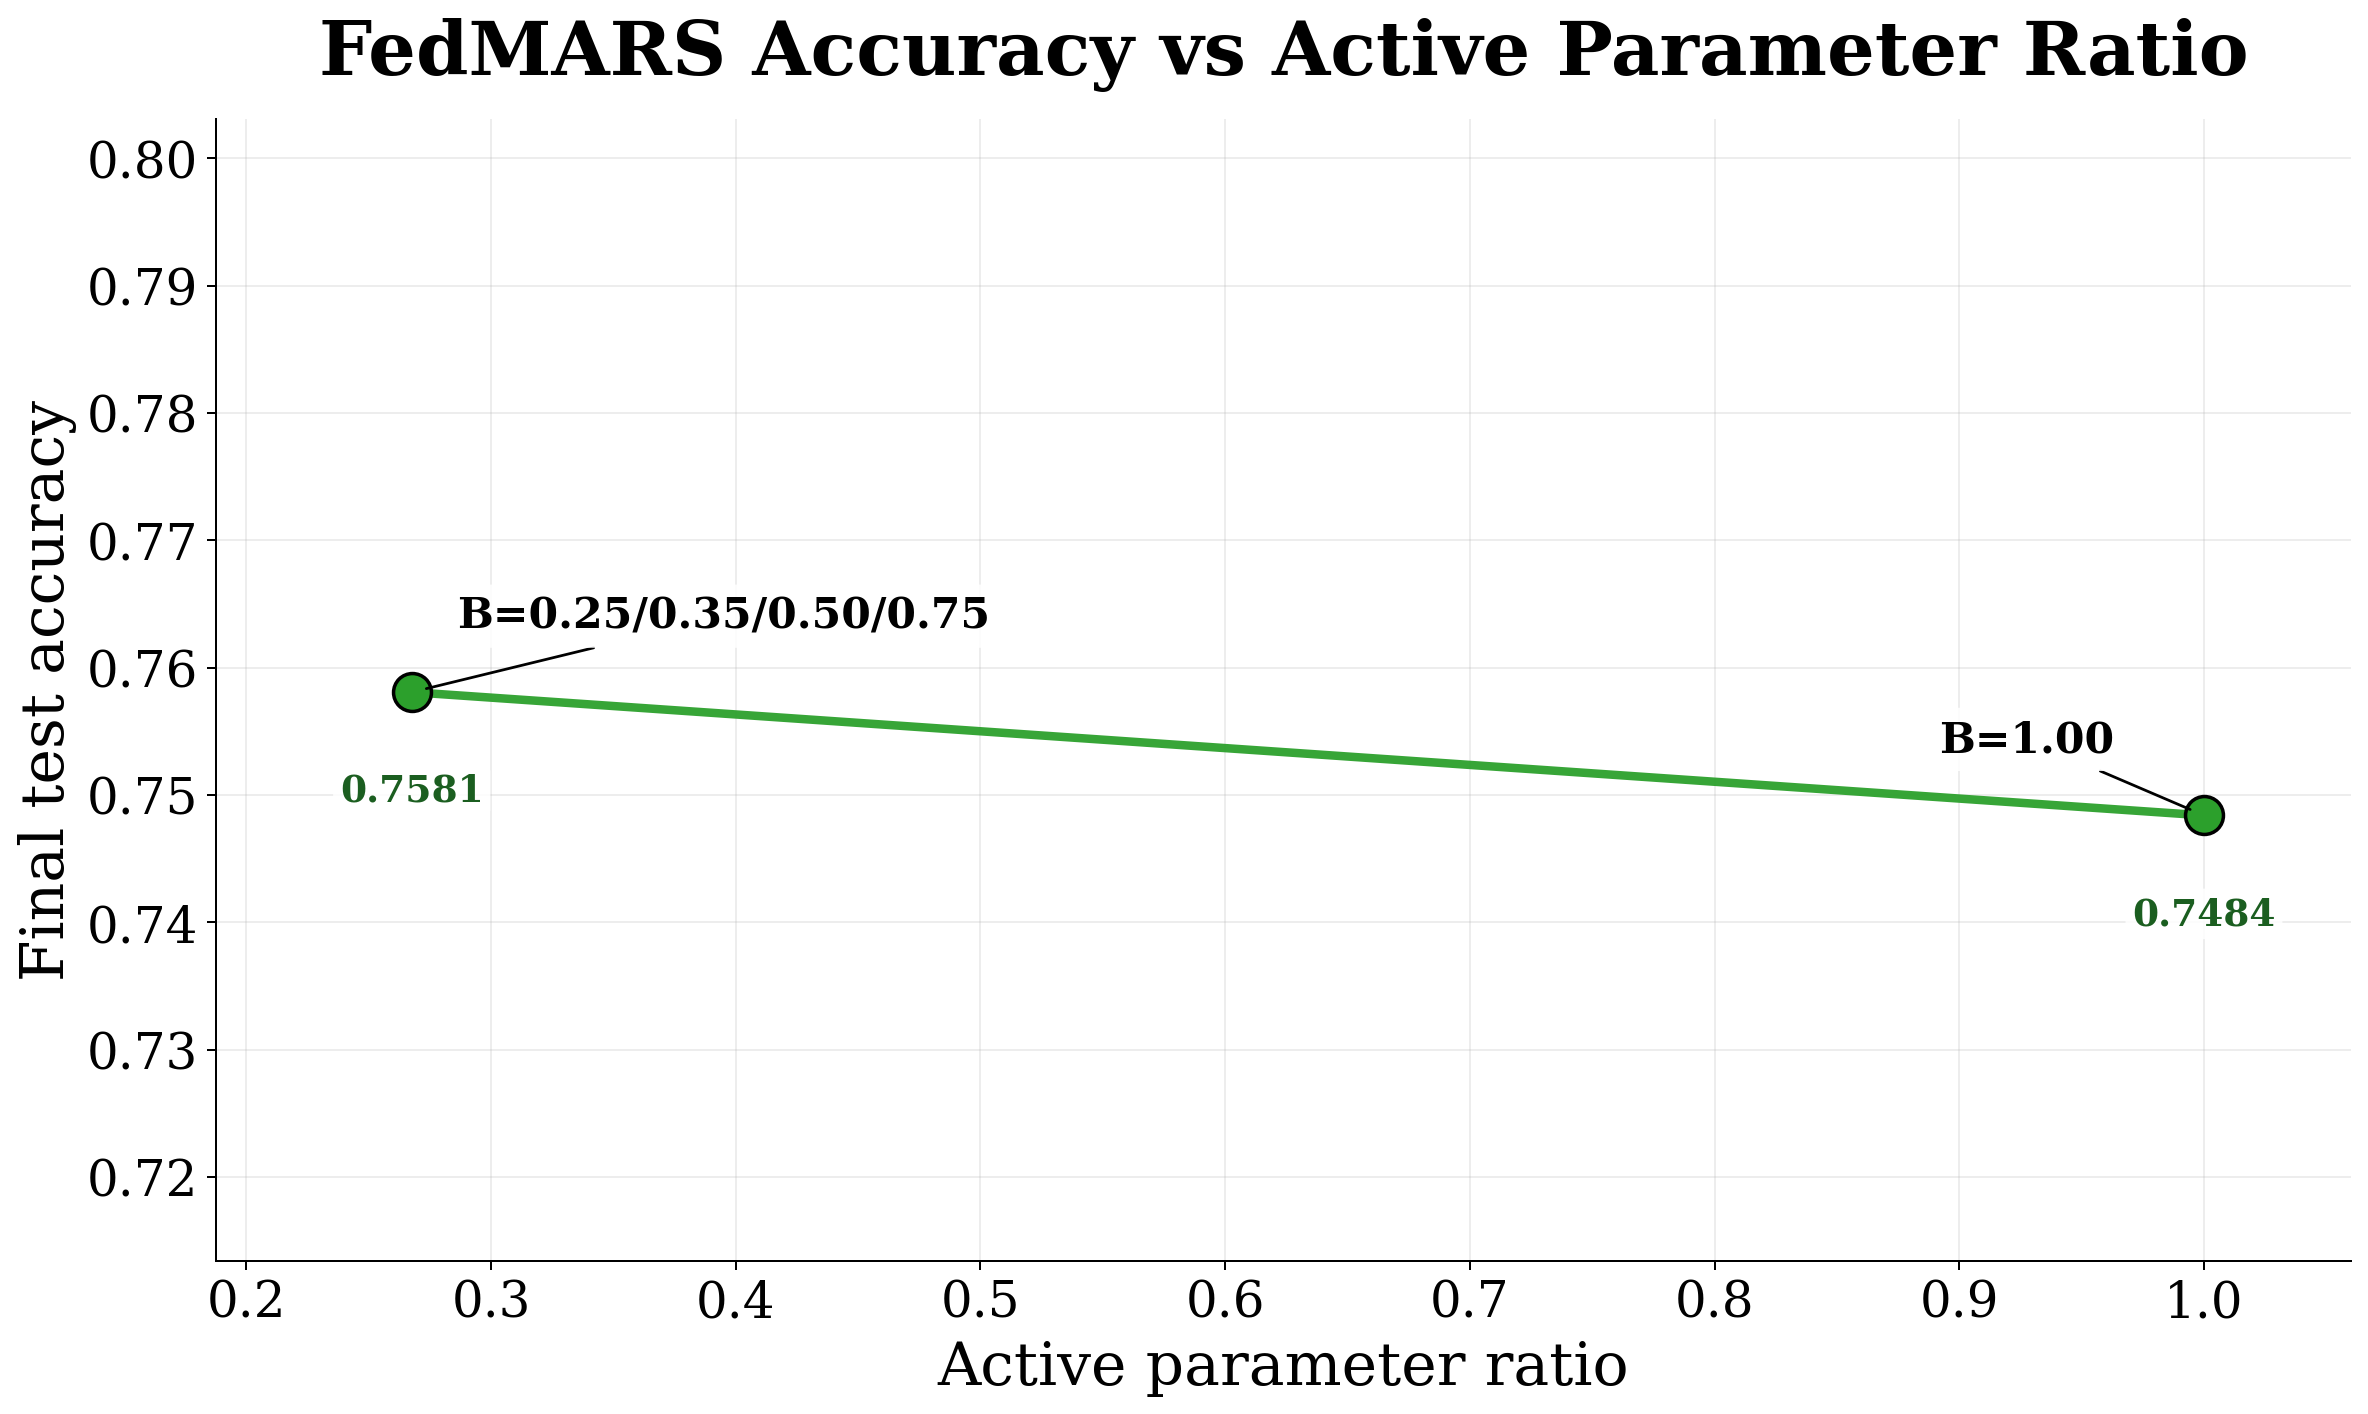

In [7]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTDIR = "validation5_fedmars_only_outputs"
os.makedirs(OUTDIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "font.family": "serif",
    "font.size": 18,
    "axes.titlesize": 30,
    "axes.labelsize": 24,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "axes.grid": True,
    "grid.alpha": 0.22,
})

def _norm(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())

def _find_col(df, names):
    cols = list(df.columns)
    norm_map = {_norm(c): c for c in cols}
    for n in names:
        if _norm(n) in norm_map:
            return norm_map[_norm(n)]
    for n in names:
        key = _norm(n)
        for c in cols:
            if key in _norm(c):
                return c
    return None

source_df = None

for name in [
    "fed",
    "fedmars_budget_df",
    "budget_df",
    "budget_summary_df",
    "fedmars_budget_sensitivity_df",
]:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        source_df = globals()[name].copy()
        break

if source_df is None:
    for fn in [
        "fedmars_budget_sensitivity_numeric.csv",
        "validation5_fedmars_only_outputs/fedmars_budget_sensitivity_numeric.csv",
        "table_A5_1_fedmars_budget_sensitivity.csv",
        "validation5_fedmars_only_outputs/table_A5_1_fedmars_budget_sensitivity.csv",
    ]:
        if os.path.exists(fn):
            source_df = pd.read_csv(fn)
            break

if source_df is None:
    raise RuntimeError("No FedMARS budget-sensitivity dataframe or CSV found.")

df = source_df.copy()

budget_col = _find_col(df, ["budget_fraction", "budget fraction", "budget"])
acc_col = _find_col(df, ["final_acc", "final_test_accuracy_mean", "final test accuracy", "final_accuracy"])
active_col = _find_col(df, ["active_ratio", "mean_active_parameter_ratio", "active parameter ratio"])

if budget_col is None or acc_col is None or active_col is None:
    raise RuntimeError("Need budget, final accuracy, and active parameter ratio columns.")

plot_df = pd.DataFrame({
    "budget": pd.to_numeric(df[budget_col].astype(str).str.extract(r"([-+]?\d*\.\d+|\d+)")[0], errors="coerce"),
    "accuracy": pd.to_numeric(df[acc_col].astype(str).str.extract(r"([-+]?\d*\.\d+|\d+)")[0], errors="coerce"),
    "active_ratio": pd.to_numeric(df[active_col].astype(str).str.extract(r"([-+]?\d*\.\d+|\d+)")[0], errors="coerce"),
})

plot_df = plot_df.dropna(subset=["budget", "accuracy", "active_ratio"]).copy()
plot_df = plot_df[plot_df["budget"] != 0.15].copy()
plot_df = plot_df.sort_values("budget").reset_index(drop=True)

if plot_df.empty:
    raise RuntimeError("No valid FedMARS budget-sensitivity rows found.")

grouped = (
    plot_df
    .groupby(["active_ratio", "accuracy"], as_index=False)
    .agg(budgets=("budget", lambda x: sorted(list(x))))
)

grouped["budget_label"] = grouped["budgets"].apply(
    lambda xs: "B=" + "/".join([f"{x:.2f}" for x in xs])
)

fig, ax = plt.subplots(figsize=(13.5, 8.2))

ax.plot(
    plot_df["active_ratio"],
    plot_df["accuracy"],
    color="#2ca02c",
    linewidth=3.4,
    alpha=0.95,
    zorder=2,
)

ax.scatter(
    grouped["active_ratio"],
    grouped["accuracy"],
    s=230,
    color="#2ca02c",
    edgecolor="black",
    linewidth=1.4,
    zorder=4,
)

xmin = max(0.0, plot_df["active_ratio"].min() - 0.08)
xmax = min(1.08, plot_df["active_ratio"].max() + 0.06)
ymin = max(0.0, plot_df["accuracy"].min() - 0.035)
ymax = min(1.0, plot_df["accuracy"].max() + 0.045)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

for _, r in grouped.iterrows():
    x = float(r["active_ratio"])
    y = float(r["accuracy"])
    label = str(r["budget_label"])

    if x < 0.5:
        xytext = (18, 22)
        ha = "left"
    else:
        xytext = (-36, 22)
        ha = "right"

    ax.annotate(
        label,
        xy=(x, y),
        xytext=xytext,
        textcoords="offset points",
        ha=ha,
        va="bottom",
        fontsize=17,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=1.1,
            shrinkA=0,
            shrinkB=6,
        ),
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
        zorder=6,
    )

    ax.annotate(
        f"{y:.4f}",
        xy=(x, y),
        xytext=(0, -32),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=15,
        fontweight="bold",
        color="#1b5e20",
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
        zorder=6,
    )

ax.set_title("FedMARS Accuracy vs Active Parameter Ratio", fontweight="bold", pad=18)
ax.set_xlabel("Active parameter ratio")
ax.set_ylabel("Final test accuracy")

ax.grid(True, alpha=0.22)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()

plt.savefig(os.path.join(OUTDIR, "A5_fedmars_accuracy_vs_active_parameter_ratio_fixed.png"), dpi=600, bbox_inches="tight")
plt.savefig(os.path.join(OUTDIR, "A5_fedmars_accuracy_vs_active_parameter_ratio_fixed.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(OUTDIR, "A5_fedmars_accuracy_vs_active_parameter_ratio_fixed.svg"), bbox_inches="tight")

plt.show()
